# AI624 Assignment 2: Pruning ResNet-18 on CIFAR-10

This notebook contains the complete experiment implementation, saved results, graphs, and analysis for Tasks 0-3.

All displayed measurements come from the completed T4 GPU experiment. The cells have been reorganized without re-execution; blank execution counts reflect that organization. The saved outputs can be read without running the notebook. Executing the task cells would run the experiments again.


## Authorship and acknowledgment

I have used OpenAI Codex to write original experiment code, explain pruning methods, execute the experiments, debug the implementation, create plots, and draft the report 1 time. Here, one time means one continuous assignment assistance session, including iterative tool calls and corrections. The measured results were produced by executing the supplied code. The model architecture and pretrained weights are attributed to Huy Phan's public repository; the pruning methods are attributed to their research papers. This is an AI-assisted submission, and does not claim that AI-generated work was independently handwritten.


## Experiment settings


All final experiments use one NVIDIA Tesla T4 GPU session, FP32, batch size 128, and 3 x 32 x 32 RGB inputs. The requested final pruning budget is 70% of Conv2d and Linear weights. Biases and normalization parameters are excluded from that denominator. Model parameter counts include all trainable tensors. Tasks 0, 1, and 3 start from exactly the same checkpoint; Task 2 starts from a separately saved random initialization. The random seed is 624.

| Setting           | Value                                                            |
|:------------------|:-----------------------------------------------------------------|
| python            | 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]               |
| torch             | 2.11.0+cu128                                                     |
| torchvision       | 0.26.0+cu128                                                     |
| cuda              | 12.8                                                             |
| cudnn             | 91900                                                            |
| gpu               | Tesla T4                                                         |
| cpu               | x86_64                                                           |
| gpu_total_MB      | 15637.086208                                                     |
| repository_commit | 641cac24371b17052b9bb6e56af1c83b5e97cd7f                         |
| checkpoint_sha256 | 72d30ca70e7d54e24a26628113604c40bc872eb8dc7a44f50ec58c3a1400f1b0 |

The upstream architecture is loaded directly from `cifar10_models/resnet.py`, including its stem max-pooling operation. Loading uses strict key and shape checks and verifies every state tensor against the checkpoint. The Box weights URL returned 404 during setup, so the archive came from the official Google Drive backup linked in the repository README. CIFAR-10 came from a byte-identical mirror because the original host was unusually slow. Torchvision checks the official archive and extracted batch MD5 hashes before use. The expected archive MD5 is `c58f30108f718f92721af3b95e74349a`.


### Data and preprocessing

The official 50,000 training images are divided by a seeded, class-stratified split into 45,000 optimization and 5,000 validation images. The official 10,000-image test set remains separate. The train metrics in final tables evaluate all 50,000 official training images without augmentation; the epoch curves evaluate the 45,000 augmented optimization images. Therefore these two training accuracy quantities need not match. The validation split was not used for gradient updates here, but the supplied pretrained checkpoint was originally trained on the original training set: validation results in Tasks 1 and 3 are not an unseen-pretraining generalization estimate. Final test results are the main generalization comparison.

Each image is divided by 255 and normalized with channel means `(0.4914, 0.4822, 0.4465)` and standard deviations `(0.2471, 0.2435, 0.2616)`. Training uses four-pixel constant padding, a random 32 x 32 crop, and horizontal flipping with probability 0.5. Validation, calibration, profiling, and final evaluation use normalization only. Images are cached as uint8 tensors on the GPU; the deterministic batch iterator shuffles and augments with seed plus epoch, avoiding CPU transfer bottlenecks. The last incomplete evaluation batch is included. Profiling always uses complete batches of 128.


### Metric definitions

Top-1 and Top-5 are percentages. Macro-F1 is on a 0 to 1 scale and gives each class equal weight. With class confusion counts,

$$F_{1,c}=\frac{2TP_c}{2TP_c+FP_c+FN_c}, \qquad F_{1,\mathrm{macro}}=\frac{1}{10}\sum_{c=1}^{10}F_{1,c}.$$

A convolution uses $H_oW_oC_o(C_i/g)k_hk_w$ MACs per image; a linear layer uses $d_{in}d_{out}$. We report $\mathrm{FLOPs}=2\,\mathrm{MACs}$, counting the multiply and add separately. This is an analytical Conv/Linear count, excluding BatchNorm, activation, pooling, bias, data preparation, and sparse conversion operations. The `ideal_nonzero_MACs` field is only a theoretical zero-skipping count and is not an executed operation count. Serialized MB means decimal bytes divided by $10^6$.


### Common latency, memory, and energy procedure

All models are evaluated in inference mode with the same ten normalized GPU-resident test batches. After 20 warm-up forwards and synchronization, 100 forward latencies are measured using CUDA events with synchronization at the end of each forward. Mean and standard deviation are saved. PyTorch allocated GPU memory is sampled after each forward; peak allocation is reset before each measured batch, and the largest batch peak is reported. Average memory is the arithmetic mean of post-forward allocations, not a continuous time average. Final profiling reloads each checkpoint after training has finished, with no live optimizer, parameter gradients, or GPU pruning masks. The common dataset cache contributes to absolute allocation. Incremental forward peak is also saved; these measurements are not whole-device NVML memory usage. All final metric files and batch CSVs contain this clean inference-only profiling pass.

GPU energy integrates NVML whole-board power, sampled approximately every 20 ms, during three independent inference windows of at least two seconds. Each window is divided by its actual completed batch count; the table gives the mean joules per batch. These are board-energy estimates, include idle board power and synchronization overhead, and are not process-isolated or wall-socket measurements. CPU energy uses package-level RAPL counters if accessible; unavailable counters are recorded as `N/A`, never zero. The execution environment did not expose host CPU power counters to the guest. CPU energy cannot be measured reliably from these guest permissions; this requested metric is explicitly reported as unavailable rather than invented. Raw per-batch timing/memory CSVs and per-window energy JSONs are included.


## Setup and shared functions

The project directory is the notebook's working directory. No platform-specific paths are used. Reproduction requires the recorded Python dependencies and a CUDA-enabled GPU; viewing the saved outputs does not require running any cell.

The batch iterator, model architecture, preprocessing, seeds, optimizers, pruning rules, and profiling procedure are unchanged.


In [ ]:

from pathlib import Path
import copy, gc, hashlib, io, json, math, os, platform, random, subprocess, sys, time
import threading, zipfile
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.nn import functional as F
import torchvision
from torchvision.datasets import CIFAR10
import matplotlib

matplotlib.use("Agg")
import matplotlib.pyplot as plt

ROOT = Path.cwd()
ROOT.mkdir(exist_ok=True)
for folder in ["results", "figures", "checkpoints", "source"]:
    (ROOT / folder).mkdir(exist_ok=True)
SEED = 624
BATCH = 128
TARGET = 0.70
FT_EPOCHS = 12
SCRATCH_EPOCHS = 50
STRUCT_EPOCHS = 18
DEVICE = "cuda"
MEAN = (0.4914, 0.4822, 0.4465)
STD = (0.2471, 0.2435, 0.2616)
UPSTREAM_COMMIT = "641cac24371b17052b9bb6e56af1c83b5e97cd7f"
CHECKPOINT_SHA256 = "72d30ca70e7d54e24a26628113604c40bc872eb8dc7a44f50ec58c3a1400f1b0"




from IPython.display import Image, display


#### Reproducible random seeds


In [ ]:
def seed_all(seed=SEED):
    """Set the Python, NumPy, and PyTorch random seeds used by this run."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


#### Save measurements


In [ ]:
def save_json(name, data):
    """Save measured values or experiment metadata in the results directory."""
    (ROOT / "results" / name).write_text(
        json.dumps(data, indent=2, allow_nan=False), encoding="utf-8"
    )


#### Save a model state on the CPU


In [ ]:
def cpu_state(model):
    """Copy a model's complete state to CPU memory for a portable checkpoint."""
    return {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}


#### Identify weights eligible for pruning


In [ ]:
def eligible(model):
    """Return named Conv2d and Linear layers. Only their weights are pruned."""
    return {
        n: m for n, m in model.named_modules() if isinstance(m, (nn.Conv2d, nn.Linear))
    }


#### Create the required ResNet-18 model


In [ ]:
def fresh(state=None):
    """Build the required upstream ResNet-18 and optionally load a saved state.

    BatchNorm parameters and the architecture remain those of the original model.
    """
    model = resnet18(pretrained=False)
    if state is not None:
        model.load_state_dict(state, strict=True)
    for mod in model.modules():
        if isinstance(mod, nn.ReLU):
            mod.inplace = False
    return model.to(DEVICE)


#### Prepare normalized image batches


In [ ]:
class TensorBatches:
    """The existing GPU-cached alternative to a PyTorch DataLoader.

    x contains uint8 images; y contains class labels. The batches method applies
    normalization and, for training only, the recorded crop and flip operations.
    This implementation is retained to preserve the original experiment exactly.
    """

    def __init__(self, x, y, indices, augment=False):
        self.x, self.y = x, y
        self.indices = torch.as_tensor(indices, device=DEVICE)
        self.augment = augment

    def __len__(self):
        return math.ceil(len(self.indices) / BATCH)

    def batches(self, epoch=0):
        gen = torch.Generator(device=DEVICE).manual_seed(SEED + epoch)
        ids = self.indices
        if self.augment:
            ids = ids[torch.randperm(len(ids), generator=gen, device=DEVICE)]
        mean = torch.tensor(MEAN, device=DEVICE).view(1, 3, 1, 1)
        std = torch.tensor(STD, device=DEVICE).view(1, 3, 1, 1)
        for pos in range(0, len(ids), BATCH):
            ix = ids[pos : pos + BATCH]
            x = self.x[ix].float().div_(255)
            if self.augment:
                b = len(x)
                padded = F.pad(x, (4, 4, 4, 4))
                oy = torch.randint(9, (b, 1, 1), generator=gen, device=DEVICE)
                ox = torch.randint(9, (b, 1, 1), generator=gen, device=DEVICE)
                yy = oy + torch.arange(32, device=DEVICE).view(1, 32, 1)
                xx = ox + torch.arange(32, device=DEVICE).view(1, 1, 32)
                x = (
                    padded.permute(0, 2, 3, 1)[
                        torch.arange(b, device=DEVICE)[:, None, None], yy, xx
                    ]
                    .permute(0, 3, 1, 2)
                    .contiguous()
                )
                flip = torch.rand(b, generator=gen, device=DEVICE) < 0.5
                x[flip] = x[flip].flip(-1)
            yield (x - mean) / std, self.y[ix]


#### Load the pretrained checkpoint and dataset


In [ ]:
def setup():
    """Load the required architecture, checkpoint, data splits, and batch iterators.

    Creates shared module state: DENSE is the pretrained state; TRAIN is the
    optimization split; TRAIN_EVAL evaluates the full training set; VALID and
    TEST are evaluation splits; CALIB is the GraSP calibration subset.
    Calling this function can download files and requires a CUDA GPU.
    """
    global resnet18, DENSE, TRAIN, TRAIN_EVAL, VALID, TEST, CALIB, ENV
    assert torch.cuda.is_available(), "A CUDA-enabled GPU is required to run the experiments."
    torch.set_num_threads(2)
    seed_all()
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    torch.backends.cuda.matmul.allow_tf32 = False
    torch.backends.cudnn.allow_tf32 = False
    repo = ROOT / "source" / "PyTorch_CIFAR10"
    if not repo.exists():
        subprocess.run(
            [
                "git",
                "clone",
                "--depth",
                "1",
                "https://github.com/huyvnphan/PyTorch_CIFAR10",
                str(repo),
            ],
            check=True,
        )
        current = subprocess.check_output(
            ["git", "-C", str(repo), "rev-parse", "HEAD"], text=True
        ).strip()
        if current != UPSTREAM_COMMIT:
            subprocess.run(
                [
                    "git",
                    "-C",
                    str(repo),
                    "fetch",
                    "--depth",
                    "1",
                    "origin",
                    UPSTREAM_COMMIT,
                ],
                check=True,
            )
            subprocess.run(
                ["git", "-C", str(repo), "checkout", UPSTREAM_COMMIT], check=True
            )
    sys.path.insert(0, str(repo))
    from cifar10_models.resnet import resnet18 as upstream_resnet18

    resnet18 = upstream_resnet18
    checkpoint = ROOT / "checkpoints" / "resnet18.pt"
    if not checkpoint.exists():
        import requests

        archive = ROOT / "weights.zip"
        url = (
            "https://rutgers.box.com/shared/static/gkw08ecs797j2et1ksmbg1w5t3idf5r5.zip"
        )
        print("Downloading official weights archive...", flush=True)
        try:
            with requests.get(url, stream=True, timeout=180) as response:
                response.raise_for_status()
                with archive.open("wb") as f:
                    for chunk in response.iter_content(2**20):
                        f.write(chunk)
        except requests.RequestException as error:
            print(
                "Box unavailable; using the official README Google Drive backup:",
                error,
                flush=True,
            )
            import gdown

            gdown.download(
                id="17fmN8eQdLpq2jIMQ_X0IXDPXfI9oVWgq", output=str(archive), quiet=False
            )
        with zipfile.ZipFile(archive) as z:
            names = [
                n
                for n in z.namelist()
                if n.endswith("/resnet18.pt") or n == "resnet18.pt"
            ]
            assert len(names) == 1, names
            checkpoint.write_bytes(z.read(names[0]))
    assert (
        hashlib.sha256(checkpoint.read_bytes()).hexdigest() == CHECKPOINT_SHA256
    ), "Unexpected pretrained checkpoint hash."
    DENSE = torch.load(checkpoint, map_location="cpu", weights_only=True)
    model = fresh(DENSE)
    assert set(DENSE) == set(model.state_dict())
    assert all(torch.equal(v.cpu(), DENSE[k]) for k, v in model.state_dict().items())
    del model
    # Byte-identical mirror; torchvision verifies the official archive and batch MD5s.
    CIFAR10.url = (
        "https://data.brainchip.com/dataset-mirror/cifar10/cifar-10-python.tar.gz"
    )
    tr = CIFAR10(str(ROOT / "data"), train=True, download=True)
    te = CIFAR10(str(ROOT / "data"), train=False, download=True)
    xtr = torch.tensor(tr.data, device=DEVICE).permute(0, 3, 1, 2).contiguous()
    ytr = torch.tensor(tr.targets, device=DEVICE)
    xte = torch.tensor(te.data, device=DEVICE).permute(0, 3, 1, 2).contiguous()
    yte = torch.tensor(te.targets, device=DEVICE)
    rng = np.random.default_rng(SEED)
    train_ids, val_ids, cal_ids = [], [], []
    labels = np.asarray(tr.targets)
    for c in range(10):
        ids = rng.permutation(np.flatnonzero(labels == c))
        val_ids.extend(ids[:500])
        train_ids.extend(ids[500:])
        cal_ids.extend(ids[500:520])
    TRAIN = TensorBatches(xtr, ytr, train_ids, True)
    TRAIN_EVAL = TensorBatches(xtr, ytr, np.arange(50000))
    VALID = TensorBatches(xtr, ytr, val_ids)
    TEST = TensorBatches(xte, yte, np.arange(10000))
    CALIB = TensorBatches(xtr, ytr, cal_ids)
    save_json(
        "split_indices.json",
        {
            "train": list(map(int, train_ids)),
            "validation": list(map(int, val_ids)),
            "calibration": list(map(int, cal_ids)),
        },
    )
    ENV = {
        "python": sys.version,
        "torch": torch.__version__,
        "torchvision": torchvision.__version__,
        "cuda": torch.version.cuda,
        "cudnn": torch.backends.cudnn.version(),
        "gpu": torch.cuda.get_device_name(0),
        "gpu_total_MB": torch.cuda.get_device_properties(0).total_memory / 1e6,
        "cpu": platform.processor(),
        "batch_size": BATCH,
        "input": [3, 32, 32],
        "seed": SEED,
        "mean": MEAN,
        "std": STD,
        "train_samples": 45000,
        "validation_samples": 5000,
        "test_samples": 10000,
        "checkpoint_sha256": hashlib.sha256(checkpoint.read_bytes()).hexdigest(),
        "repository_commit": (
            subprocess.check_output(
                ["git", "-C", str(repo), "rev-parse", "HEAD"], text=True
            ).strip()
            if (repo / ".git").exists()
            else UPSTREAM_COMMIT
        ),
        "architecture_sha256": hashlib.sha256(
            (repo / "cifar10_models" / "resnet.py").read_bytes()
        ).hexdigest(),
        "target_sparsity": TARGET,
        "finetuning_epochs": FT_EPOCHS,
        "scratch_epochs": SCRATCH_EPOCHS,
        "structured_epochs": STRUCT_EPOCHS,
    }
    save_json("environment.json", ENV)
    print(json.dumps(ENV, indent=2), flush=True)


## Task 0: Dense pretrained baseline

The following helpers calculate classification metrics and measure inference resources. `x` and `y` are images and labels; `cm` is the confusion matrix. The baseline is the required pretrained ResNet-18, with the repository's original normalization and max-pooling layer.


#### Calculate accuracy, macro-F1, and loss


In [ ]:
@torch.inference_mode()
def evaluate(model, loader):
    """Evaluate a model without updating weights. Return accuracy, F1, and loss.

    x and y are images and labels; out contains class scores; cm is the
    confusion matrix with true classes in rows and predictions in columns.
    tp contains the correctly classified count for each class.
    """
    model.eval()
    cm = torch.zeros(10, 10, dtype=torch.int64, device=DEVICE)
    total, top5, loss_sum = 0, 0, 0.0
    for x, y in loader.batches():
        out = model(x)
        pred = out.argmax(1)
        cm += torch.bincount(y * 10 + pred, minlength=100).reshape(10, 10)
        top5 += (out.topk(5, dim=1).indices == y[:, None]).any(1).sum().item()
        total += len(y)
        loss_sum += F.cross_entropy(out, y, reduction="sum").item()
    cm = cm.cpu().numpy()
    tp = np.diag(cm)
    f1 = np.divide(
        2 * tp,
        cm.sum(0) + cm.sum(1),
        out=np.zeros(10, dtype=float),
        where=(cm.sum(0) + cm.sum(1)) != 0,
    )
    return {
        "n": total,
        "top1": float(100 * tp.sum() / total),
        "top5": float(100 * top5 / total),
        "macro_f1": float(f1.mean()),
        "loss": loss_sum / total,
    }


#### Evaluate the full training and test sets


In [ ]:
def full_metrics(model):
    """Evaluate the complete official training and test sets without augmentation."""
    return {
        p + "_" + k: v
        for p, loader in [("train", TRAIN_EVAL), ("test", TEST)]
        for k, v in evaluate(model, loader).items()
    }


#### Count MACs and FLOPs


In [ ]:
@torch.inference_mode()
def operation_counts(model):
    """Count Conv/Linear MACs for one image and report FLOPs as twice MACs.

    The ideal nonzero count is theoretical; dense kernels still process zeros.
    """
    rows = []
    hooks = []

    def hook(name, m, x, y):
        if isinstance(m, nn.Conv2d):
            mac = y.numel() * m.weight[0].numel()
            nz = int((m.weight != 0).sum()) * y.shape[-2] * y.shape[-1]
        else:
            mac = m.in_features * m.out_features
            nz = int((m.weight != 0).sum())
        rows.append({"layer": name, "dense_MACs": mac, "ideal_nonzero_MACs": nz})

    for n, m in eligible(model).items():
        hooks.append(m.register_forward_hook(lambda m, x, y, n=n: hook(n, m, x, y)))
    model.eval()(torch.zeros(1, 3, 32, 32, device=DEVICE))
    for h in hooks:
        h.remove()
    return {
        "MACs": sum(r["dense_MACs"] for r in rows),
        "FLOPs": 2 * sum(r["dense_MACs"] for r in rows),
        "ideal_nonzero_MACs": sum(r["ideal_nonzero_MACs"] for r in rows),
    }


#### Sample GPU power


In [ ]:
class PowerSampler:
    """Sample NVML whole-board GPU power in a background thread.

    Integrating the power samples estimates energy for a measured interval.
    Unavailable hardware readings are recorded as unavailable rather than zero.
    """

    def __init__(self):
        self.samples = []
        self.stop = threading.Event()
        self.handle = None
        self.error = None
        try:
            import pynvml

            self.nv = pynvml
            pynvml.nvmlInit()
            self.handle = pynvml.nvmlDeviceGetHandleByIndex(0)
            pynvml.nvmlDeviceGetPowerUsage(self.handle)
        except Exception as e:
            self.error = str(e)

    def read(self):
        if self.handle is None or self.error:
            return
        try:
            self.samples.append(
                (
                    time.perf_counter(),
                    self.nv.nvmlDeviceGetPowerUsage(self.handle) / 1000,
                )
            )
        except Exception as e:
            self.error = str(e)

    def start(self):
        self.read()

        def worker():
            while not self.stop.wait(0.02):
                self.read()

        self.thread = threading.Thread(target=worker, daemon=True)
        self.thread.start()

    def finish(self):
        self.stop.set()
        self.thread.join()
        self.read()
        if len(self.samples) < 2 or self.error:
            return None
        return float(
            np.trapezoid([x[1] for x in self.samples], x=[x[0] for x in self.samples])
        )


#### Read available CPU energy counters


In [ ]:
def rapl_read():
    """Read accessible CPU package-energy counters, returning an empty map if absent."""
    values = {}
    for path in Path("/sys/class/powercap").glob("intel-rapl:[0-9]*/energy_uj"):
        if path.parent.name.count(":") != 1:
            continue
        try:
            values[str(path)] = (
                int(path.read_text()),
                int((path.parent / "max_energy_range_uj").read_text()),
            )
        except OSError:
            pass
    return values


#### Measure latency, memory, and energy


In [ ]:
@torch.inference_mode()
def profile(model, name, counts):
    """Measure the unchanged latency, memory, and energy protocol for one model.

    Uses 20 warm-up forwards, 100 timed batches, and three energy windows.
    This function performs inference and writes profiling result files.
    """
    gc.collect()
    torch.cuda.empty_cache()
    model.eval()
    xs = []
    for i, (x, y) in enumerate(TEST.batches()):
        if i == 10:
            break
        xs.append(x)
    for i in range(20):
        model(xs[i % 10])
    torch.cuda.synchronize()
    baseline_mem = torch.cuda.memory_allocated()
    samples = []
    mem = []
    peaks = []
    for i in range(100):
        torch.cuda.reset_peak_memory_stats()
        a = torch.cuda.Event(enable_timing=True)
        b = torch.cuda.Event(enable_timing=True)
        a.record()
        out = model(xs[i % 10])
        b.record()
        b.synchronize()
        samples.append(a.elapsed_time(b))
        mem.append(torch.cuda.memory_allocated())
        peaks.append(torch.cuda.max_memory_allocated())
        del out
    # Three independent >=2-second windows improve board-energy integration.
    sampler = PowerSampler()
    energy_rows = []
    for repeat in range(3):
        sampler = PowerSampler()
        cpu_before = rapl_read()
        sampler.start()
        start = time.perf_counter()
        n = 0
        while time.perf_counter() - start < 2:
            model(xs[n % 10])
            torch.cuda.synchronize()
            n += 1
        elapsed = time.perf_counter() - start
        gpu_j = sampler.finish()
        cpu_after = rapl_read()
        cpu_j = None
        if cpu_before and cpu_before.keys() == cpu_after.keys():
            cpu_j = (
                sum((cpu_after[k][0] - v[0]) % v[1] for k, v in cpu_before.items())
                / 1e6
            )
        energy_rows.append(
            {
                "batches": n,
                "seconds": elapsed,
                "gpu_J": gpu_j,
                "cpu_J": cpu_j,
                "gpu_J_per_batch": None if gpu_j is None else gpu_j / n,
                "cpu_J_per_batch": None if cpu_j is None else cpu_j / n,
            }
        )
    pd.DataFrame(
        {
            "latency_ms": samples,
            "allocated_MB": np.array(mem) / 1e6,
            "peak_MB": np.array(peaks) / 1e6,
        }
    ).to_csv(ROOT / "results" / f"{name}_profile_batches.csv", index=False)
    save_json(f"{name}_energy.json", energy_rows)

    def avg(field):
        vals = [r[field] for r in energy_rows if r[field] is not None]
        return float(np.mean(vals)) if vals else None

    result = {
        **counts,
        "latency_ms": float(np.mean(samples)),
        "latency_std_ms": float(np.std(samples)),
        "peak_GPU_MB": max(peaks) / 1e6,
        "average_GPU_MB": float(np.mean(mem)) / 1e6,
        "incremental_peak_GPU_MB": (max(peaks) - baseline_mem) / 1e6,
        "gpu_J_per_batch": avg("gpu_J_per_batch"),
        "cpu_J_per_batch": avg("cpu_J_per_batch"),
        "energy_note": "GPU: integrated NVML board power, not process-isolated. CPU: RAPL package counter when exposed; otherwise unavailable.",
        "gpu_power_error": sampler.error,
        "profile_batch_size": BATCH,
        "profile_batches": 100,
    }
    return result


#### Save and measure a model


In [ ]:
def assess(model, name, masks=None, sparse=True):
    """Evaluate, save, verify, and profile a final model and its COO variant.

    This writes measured result files. Final inference-only profiles are
    subsequently produced by final_validation using the same saved checkpoints.
    """
    print("Evaluating and profiling", name, flush=True)
    metrics = full_metrics(model)
    counts = operation_counts(model)
    metrics["parameters"] = sum(p.numel() for p in model.parameters())
    path = ROOT / "checkpoints" / f"{name}_dense.pt"
    torch.save(cpu_state(model), path)
    metrics["dense_MB"] = path.stat().st_size / 1e6
    if masks is not None:
        rows = verify_masks(model, masks)
        pd.DataFrame(rows).to_csv(ROOT / "results" / f"{name}_layers.csv", index=False)
        metrics["overall_sparsity"] = sum(
            int((~x).sum()) for x in masks.values()
        ) / sum(x.numel() for x in masks.values())
        metrics["sparse_MB"] = save_sparse(model, masks, name)
    else:
        metrics["overall_sparsity"] = 0.0
    metrics.update(profile(model, name, counts))
    if sparse and masks is not None:
        sparse_m = coo_model(model)
        x, _ = next(TEST.batches())
        with torch.inference_mode():
            a = model.eval()(x)
            b = sparse_m(x)
            error = float((a - b).abs().max())
            torch.testing.assert_close(a, b, atol=2e-4, rtol=2e-4)
        sparse_metrics = full_metrics(sparse_m)
        model.cpu()
        gc.collect()
        torch.cuda.empty_cache()
        sparse_metrics.update(profile(sparse_m, name + "_coo", counts))
        sparse_metrics["max_logit_difference"] = error
        save_json(name + "_coo_metrics.json", sparse_metrics)
        del sparse_m
        model.to(DEVICE)
    save_json(name + "_metrics.json", metrics)
    print(json.dumps(metrics, indent=2), flush=True)
    return metrics


#### Run the dense baseline


In [ ]:
def task0():
    """Restore the pretrained baseline, evaluate and profile it, then release GPU state."""
    model = fresh(DENSE)
    result = assess(model, "baseline", sparse=False)
    assert (
        result["test_top1"] > 85
    ), "Checkpoint or preprocessing requires investigation."
    del model
    gc.collect()
    torch.cuda.empty_cache()
    return result


In [ ]:
setup()
baseline_result = task0()


{
  "environment": {
    "python": "3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]",
    "torch": "2.11.0+cu128",
    "torchvision": "0.26.0+cu128",
    "cuda": "12.8",
    "cudnn": 91900,
    "gpu": "Tesla T4",
    "gpu_total_MB": 15637.086208,
    "cpu": "x86_64",
    "batch_size": 128,
    "input": [
      3,
      32,
      32
    ],
    "seed": 624,
    "mean": [
      0.4914,
      0.4822,
      0.4465
    ],
    "std": [
      0.2471,
      0.2435,
      0.2616
    ],
    "train_samples": 45000,
    "validation_samples": 5000,
    "test_samples": 10000,
    "checkpoint_sha256": "72d30ca70e7d54e24a26628113604c40bc872eb8dc7a44f50ec58c3a1400f1b0",
    "repository_commit": "641cac24371b17052b9bb6e56af1c83b5e97cd7f",
    "target_sparsity": 0.7,
    "finetuning_epochs": 12,
    "scratch_epochs": 50,
    "structured_epochs": 18,
    "architecture_sha256": "0eb3706c924c670bfd61879053f1b32eb2039fccb239e38d44533af3550fdc03"
  },
  "final_baseline_metrics": {
    "train_n": 50000,
    

### Baseline result

The table reports every Task 0 deliverable from the saved final baseline measurements in `results/baseline_metrics.json`. Both training and test values are included for Top-5 and macro-F1.

| Metric | Dense baseline result |
|:---|:---|
| Train Top-1 accuracy | 99.8660% |
| Test Top-1 accuracy | 93.0700% |
| Train Top-5 accuracy | 99.9960% |
| Test Top-5 accuracy | 99.7400% |
| Train macro-F1 | 0.998660 |
| Test macro-F1 | 0.930700 |
| Number of model parameters | 11,173,962 |
| Serialized dense model size | 44.7717 MB |
| MACs per image | 140,186,624 |
| FLOPs per image | 280,373,248 |
| Average inference latency | 12.2287 ms per batch |
| Peak GPU memory usage | 339.5205 MB |
| Average GPU memory usage | 267.6326 MB |
| CPU energy consumption | N/A - CPU energy counters were unavailable |
| GPU energy consumption | 0.8294 J per batch |

Measurements use FP32 on the Tesla T4, with batch size 128 and 3 x 32 x 32 inputs. Train metrics cover all 50,000 training images, and test metrics cover all 10,000 test images. MACs and FLOPs are per image; FLOPs count one multiply and one add as two operations. Model size and memory use decimal MB.

Latency is averaged over 100 batches after 20 warm-up forwards; its standard deviation is 0.1676 ms. Peak memory is the maximum allocated peak across the measured batches, while average memory is the mean post-forward allocation. Both include the common GPU dataset cache. GPU energy is the mean per-batch whole-board estimate over three inference windows of at least two seconds. CPU energy is unavailable, not zero, because the execution environment did not expose the required counters.

These are the saved final checkpoint-reload measurements. The raw task logs retain their original preliminary resource measurements; final metric files and comparison tables use the subsequent clean inference-only profiling pass. The cross-method comparison tables appear after all pruning methods.


## Task 1: Unstructured post-training pruning

The implementation first tests each layer independently, then constructs local and global masks at the same overall 70% removal target. Both models receive the same fixed-mask fine-tuning schedule. A Boolean mask keeps a weight when its value is True; False removes it.


#### Create pruning masks


In [ ]:
def masks_for(model):
    """Create one all-True weight mask for every eligible layer. True means retain."""
    return {
        n: torch.ones_like(m.weight, dtype=torch.bool)
        for n, m in eligible(model).items()
    }


#### Keep removed weights and momentum at zero


In [ ]:
@torch.no_grad()
def apply_masks(model, masks, optimizer=None):
    """Keep removed weights at zero and also clear their SGD momentum entries.

    This is called after optimizer updates so earlier removals cannot regrow.
    """
    layers = eligible(model)
    for n, mask in masks.items():
        w = layers[n].weight
        w.mul_(mask)
        if optimizer is not None:
            state = optimizer.state.get(w, {})
            if "momentum_buffer" in state:
                state["momentum_buffer"].mul_(mask)


#### Check mask and weight sparsity


In [ ]:
def verify_masks(model, masks):
    """Check every removed weight is zero and compare mask and tensor sparsity."""
    rows = []
    for n, m in eligible(model).items():
        mask = masks[n]
        masked_zero = bool(torch.all(m.weight.detach()[~mask] == 0).item())
        assert masked_zero, n
        zeros = int((m.weight.detach() == 0).sum())
        removed = int((~mask).sum())
        rows.append(
            {
                "layer": n,
                "weights": mask.numel(),
                "mask_sparsity": removed / mask.numel(),
                "actual_zero_fraction": zeros / mask.numel(),
                "extra_natural_zeros": zeros - removed,
                "remaining_ratio": float(mask.float().mean()),
                "masked_positions_zero": masked_zero,
            }
        )
    return rows


#### Rank weights across all eligible layers


In [ ]:
def prune_global(model, masks, sparsity, scores=None, largest=False):
    """Extend cumulative masks to the requested overall sparsity.

    By default, remove the smallest absolute weights. For GraSP, supplied
    signed scores are ranked with largest=True. Previously removed positions
    are excluded from selection; tied scores use stable flattened index order.
    """
    layers = eligible(model)
    total = sum(m.weight.numel() for m in layers.values())
    already = sum(int((~v).sum()) for v in masks.values())
    count = round(total * sparsity) - already
    assert count >= 0
    if count == 0:
        return masks
    all_scores = torch.cat(
        [
            (scores[n] if scores is not None else m.weight.detach().abs()).flatten()
            for n, m in layers.items()
        ]
    )
    active = torch.cat([m.flatten() for m in masks.values()])
    all_scores[~active] = -torch.inf if largest else torch.inf
    assert torch.isfinite(all_scores[active]).all()
    chosen = torch.argsort(all_scores, descending=largest, stable=True)[:count]
    active[chosen] = False
    offset = 0
    for n, m in layers.items():
        size = m.weight.numel()
        masks[n] = active[offset : offset + size].reshape_as(m.weight).clone()
        offset += size
    apply_masks(model, masks)
    return masks


### COO representation

Convolution weights are reconstructed as dense tensors on each forward pass. The linear layer uses sparse matrix multiplication. Both costs are included in the recorded COO inference measurements.


#### Run convolution from COO-stored weights


In [ ]:
class COOConv(nn.Module):
    """Store convolution weights in COO form and densify on every forward pass.

    The conversion cost is included in the recorded COO inference measurements.
    """

    def __init__(self, m):
        super().__init__()
        self.register_buffer("sparse_weight", m.weight.detach().to_sparse().coalesce())
        self.register_buffer(
            "bias", None if m.bias is None else m.bias.detach().clone()
        )
        self.stride, self.padding, self.dilation, self.groups = (
            m.stride,
            m.padding,
            m.dilation,
            m.groups,
        )

    def forward(self, x):
        return F.conv2d(
            x,
            self.sparse_weight.to_dense(),
            self.bias,
            self.stride,
            self.padding,
            self.dilation,
            self.groups,
        )


#### Run a sparse linear layer


In [ ]:
class COOLinear(nn.Module):
    """Apply the linear layer with sparse matrix multiplication and optional bias."""

    def __init__(self, m):
        super().__init__()
        self.register_buffer("sparse_weight", m.weight.detach().to_sparse().coalesce())
        self.register_buffer(
            "bias", None if m.bias is None else m.bias.detach().clone()
        )

    def forward(self, x):
        y = torch.sparse.mm(self.sparse_weight, x.t()).t()
        return y if self.bias is None else y + self.bias


#### Build the COO inference model


In [ ]:
def coo_model(model):
    """Copy a model and replace eligible layers with the COO inference wrappers."""
    out = copy.deepcopy(model)
    for n, m in list(eligible(out).items()):
        parent_name, _, name = n.rpartition(".")
        parent = out.get_submodule(parent_name) if parent_name else out
        setattr(parent, name, COOConv(m) if isinstance(m, nn.Conv2d) else COOLinear(m))
    return out.eval()


#### Save and verify sparse tensors


In [ ]:
def save_sparse(model, masks, name):
    """Save COO values, indices, shapes, masks, and the remaining dense state.

    Reload and reconstruct each sparse tensor to verify exact weight equality.
    """
    state = cpu_state(model)
    tensors = {}
    for n, m in eligible(model).items():
        key = n + ".weight"
        coo = state.pop(key).to_sparse().coalesce()
        tensors[key] = {
            "values": coo.values(),
            "indices": coo.indices(),
            "shape": tuple(coo.shape),
            "mask": masks[n].cpu(),
        }
    path = ROOT / "checkpoints" / f"{name}_coo.pt"
    torch.save({"sparse_tensors": tensors, "dense_state": state}, path)
    # Round trip checks all tensors, including shape and index accounting.
    loaded = torch.load(path, map_location="cpu", weights_only=True)
    for n, m in eligible(model).items():
        record = loaded["sparse_tensors"][n + ".weight"]
        restored = torch.sparse_coo_tensor(
            record["indices"], record["values"], record["shape"]
        ).to_dense()
        assert torch.equal(restored, m.weight.detach().cpu())
    return path.stat().st_size / 1e6


### Training helpers

The training loop masks gradients and reapplies masks after optimizer updates, including momentum entries. These same helpers are reused by the later tasks.


#### Create the shared SGD optimizer


In [ ]:
def optimizer_for(model, lr):
    """Construct the original SGD optimizer with the supplied learning rate."""
    return torch.optim.SGD(
        model.parameters(), lr=lr, momentum=0.9, weight_decay=5e-4, nesterov=True
    )


#### Train one epoch with fixed masks


In [ ]:
def train_epoch(model, optimizer, epoch, masks=None):
    """Train one epoch, masking gradients and restoring masked weights after updates.

    Returns augmented-training loss and Top-1 accuracy for the learning curves.
    """
    model.train()
    n = 0
    correct = 0
    loss_sum = 0.0
    for x, y in TRAIN.batches(epoch):
        optimizer.zero_grad(set_to_none=True)
        out = model(x)
        loss = F.cross_entropy(out, y)
        loss.backward()
        if masks is not None:
            for name, m in eligible(model).items():
                m.weight.grad.mul_(masks[name])
        optimizer.step()
        if masks is not None:
            apply_masks(model, masks, optimizer)
        n += len(y)
        correct += (out.argmax(1) == y).sum().item()
        loss_sum += loss.item() * len(y)
    return {"train_loss": loss_sum / n, "train_top1": 100 * correct / n}


#### Save learning curves


In [ ]:
def curves(history, name):
    """Save recorded epoch history and draw its loss and accuracy curves."""
    df = pd.DataFrame(history)
    df.to_csv(ROOT / "results" / f"{name}_history.csv", index=False)
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    for ax, metric, label in zip(
        axes, ["loss", "top1"], ["Cross-entropy loss", "Top-1 accuracy (%)"]
    ):
        marker = "o" if len(df) == 1 else None
        ax.plot(
            df.epoch, df["train_" + metric], label="Training (augmented)", marker=marker
        )
        ax.plot(df.epoch, df["val_" + metric], label="Validation", marker=marker)
        if len(df) == 1:
            ax.set_xticks(df.epoch)
        ax.set(xlabel="Epoch", ylabel=label, title=name.replace("_", " "))
        ax.grid(alpha=0.25)
        ax.legend()
    fig.tight_layout()
    fig.savefig(ROOT / "figures" / f"{name}_curves.png", dpi=160)
    plt.close(fig)


#### Fine-tune with the recorded schedule


In [ ]:
def finetune(model, masks, name, epochs=FT_EPOCHS):
    """Run the original SGD fine-tuning schedule and save histories and checkpoints.

    Local and global pruning receive the same seed, schedule, and epoch budget.
    """
    seed_all()
    optimizer = optimizer_for(model, 0.01)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, epochs, eta_min=0.0001
    )
    history = []
    for epoch in range(epochs):
        start = time.perf_counter()
        lr = optimizer.param_groups[0]["lr"]
        row = train_epoch(model, optimizer, epoch, masks)
        val = evaluate(model, VALID)
        row.update(
            epoch=epoch + 1,
            lr=lr,
            val_loss=val["loss"],
            val_top1=val["top1"],
            seconds=time.perf_counter() - start,
        )
        history.append(row)
        scheduler.step()
        curves(history, name)
        torch.save(
            {
                "state": cpu_state(model),
                "optimizer": optimizer.state_dict(),
                "scheduler": scheduler.state_dict(),
                "epoch": epoch + 1,
                "history": history,
                "masks": (
                    None if masks is None else {k: v.cpu() for k, v in masks.items()}
                ),
            },
            ROOT / "checkpoints" / f"{name}_resume.pt",
        )
        print(name, row, flush=True)
    if masks is not None:
        verify_masks(model, masks)
    return history


### Sensitivity and pruning procedure


#### Measure independent layer sensitivity


In [ ]:
def sensitivity():
    """Test one layer at a time at all seven required sparsity levels.

    Restore the complete pretrained state before every trial. Other layers
    remain dense, and no fine-tuning occurs during the 147 sensitivity trials.
    """
    model = fresh(DENSE)
    rows = []
    for name, layer in eligible(model).items():
        for sparsity in [0, 0.1, 0.2, 0.5, 0.7, 0.8, 0.9]:
            model.load_state_dict(DENSE, strict=True)
            with torch.no_grad():
                w = layer.weight.flatten()
                k = round(w.numel() * sparsity)
                ids = torch.argsort(w.abs(), stable=True)[:k]
                w[ids] = 0
            metrics = evaluate(model, VALID)
            rows.append({"layer": name, "sparsity": sparsity, **metrics})
        print(
            "Sensitivity",
            name,
            [(r["sparsity"], round(r["top1"], 2)) for r in rows[-7:]],
            flush=True,
        )
        pd.DataFrame(rows).to_csv(ROOT / "results" / "sensitivity.csv", index=False)
    df = pd.DataFrame(rows)
    fig, axes = plt.subplots(7, 3, figsize=(14, 23), sharex=True, sharey=True)
    for ax, (name, group) in zip(axes.flat, df.groupby("layer", sort=False)):
        ax.plot(group.sparsity * 100, group.top1, "o-")
        ax.set_title(name)
        ax.grid(alpha=0.25)
        ax.set(xlabel="Pruned weights (%)", ylabel="Validation Top-1 (%)")
    fig.tight_layout()
    fig.savefig(ROOT / "figures" / "sensitivity.png", dpi=130)
    plt.close(fig)
    del model
    return df


#### Allocate local sparsity from sensitivity


In [ ]:
def local_masks(model, df):
    """Allocate the same overall weight-removal budget using sensitivity results.

    A larger validation drop at 70 percent makes a layer less prunable.
    The original bounded allocation and rounding rule are preserved exactly.
    """
    names = list(eligible(model))
    sizes = np.array([m.weight.numel() for m in eligible(model).values()])
    drops = []
    for name in names:
        part = df[df.layer == name]
        base = float(part[part.sparsity == 0].top1.iloc[0])
        drops.append(max(0.0, base - float(part[part.sparsity == 0.7].top1.iloc[0])))
    # Continuous sensitivity-weighted water filling, exact rounded global budget.
    importance = 1 / (1 + np.asarray(drops) / 5)
    low, high = 0.0, 100.0
    for _ in range(80):
        mid = (low + high) / 2
        r = np.clip(mid * importance, 0.05, 0.90)
        if (r * sizes).sum() / sizes.sum() < TARGET:
            low = mid
        else:
            high = mid
    desired = r * sizes
    counts = np.floor(desired).astype(int)
    remain = round(TARGET * int(sizes.sum())) - int(counts.sum())
    for i in np.argsort(-(desired - counts))[:remain]:
        counts[i] += 1
    assert counts.sum() == round(TARGET * int(sizes.sum()))
    masks = masks_for(model)
    for (name, layer), count in zip(eligible(model).items(), counts):
        flat = masks[name].flatten()
        flat[
            torch.argsort(layer.weight.detach().abs().flatten(), stable=True)[:count]
        ] = False
    apply_masks(model, masks)
    save_json(
        "local_allocation.json",
        [
            {"layer": n, "drop_at_70_pp": d, "chosen_sparsity": int(k) / int(z)}
            for n, d, k, z in zip(names, drops, counts, sizes)
        ],
    )
    return masks


#### Run local and global pruning


In [ ]:
def task1():
    """Run sensitivity analysis, then compare local and global magnitude pruning.

    Each method starts from the same pretrained checkpoint and is evaluated
    before and after identical fixed-mask fine-tuning.
    """
    df = sensitivity()
    results = {}
    for method in ["local", "global"]:
        model = fresh(DENSE)
        masks = (
            local_masks(model, df)
            if method == "local"
            else prune_global(model, masks_for(model), TARGET)
        )
        assert all(bool(mask.any()) for mask in masks.values()), "A layer collapsed."
        pre = full_metrics(model)
        save_json(method + "_before_finetune.json", pre)
        print(method, "before fine-tuning", pre, flush=True)
        finetune(model, masks, method)
        results[method] = assess(model, method, masks)
        del model, masks
        gc.collect()
        torch.cuda.empty_cache()
    assert (
        abs(
            results["local"]["overall_sparsity"] - results["global"]["overall_sparsity"]
        )
        < 1e-12
    )
    return results


In [ ]:
post_training_results = task1()


Sensitivity conv1 [(0, 99.82), (0.1, 99.82), (0.2, 99.82), (0.5, 99.3), (0.7, 84.96), (0.8, 44.16), (0.9, 23.02)]
Sensitivity layer1.0.conv1 [(0, 99.82), (0.1, 99.82), (0.2, 99.82), (0.5, 99.84), (0.7, 99.78), (0.8, 99.16), (0.9, 95.8)]
Sensitivity layer1.0.conv2 [(0, 99.82), (0.1, 99.82), (0.2, 99.82), (0.5, 99.84), (0.7, 99.7), (0.8, 99.34), (0.9, 95.94)]
Sensitivity layer1.1.conv1 [(0, 99.82), (0.1, 99.84), (0.2, 99.86), (0.5, 99.86), (0.7, 99.56), (0.8, 98.64), (0.9, 97.36)]
Sensitivity layer1.1.conv2 [(0, 99.82), (0.1, 99.82), (0.2, 99.82), (0.5, 99.86), (0.7, 99.84), (0.8, 99.78), (0.9, 99.06)]
Sensitivity layer2.0.conv1 [(0, 99.82), (0.1, 99.84), (0.2, 99.86), (0.5, 99.82), (0.7, 99.12), (0.8, 95.82), (0.9, 65.5)]
Sensitivity layer2.0.conv2 [(0, 99.82), (0.1, 99.82), (0.2, 99.84), (0.5, 99.82), (0.7, 99.56), (0.8, 98.62), (0.9, 94.96)]
Sensitivity layer2.0.downsample.0 [(0, 99.82), (0.1, 99.82), (0.2, 99.84), (0.5, 99.82), (0.7, 99.7), (0.8, 99.72), (0.9, 99.72)]
Sensitivity lay

### Results and discussion


### 1. Independent layer sensitivity

Each of the 21 convolutional or linear weight tensors is pruned independently at 0%, 10%, 20%, 50%, 70%, 80%, and 90%. All state tensors are restored from the original checkpoint before each trial, and there is no fine-tuning in these trials. Accuracy is measured on the 5,000-image validation split. This prevents the test set from choosing layer allocations. Every curve is included below, and every numeric observation is in `results/sensitivity.csv`.

Largest validation accuracy losses at 70% single-layer sparsity:

| Layer          |   Drop at 70% (pp) |
|:---------------|-------------------:|
| conv1          |            14.8600 |
| layer2.0.conv1 |             0.7000 |
| layer2.1.conv1 |             0.3800 |
| layer1.1.conv1 |             0.2600 |
| layer2.0.conv2 |             0.2600 |

The most sensitive layer by this criterion is `conv1`. Sensitivity measures the effect of deleting weights in isolation. It does not guarantee that combining several individually tolerable deletions will be harmless: downstream representations and residual branch interactions can amplify their joint effect.


Independent layer sensitivity; every trial restarts from the dense checkpoint.


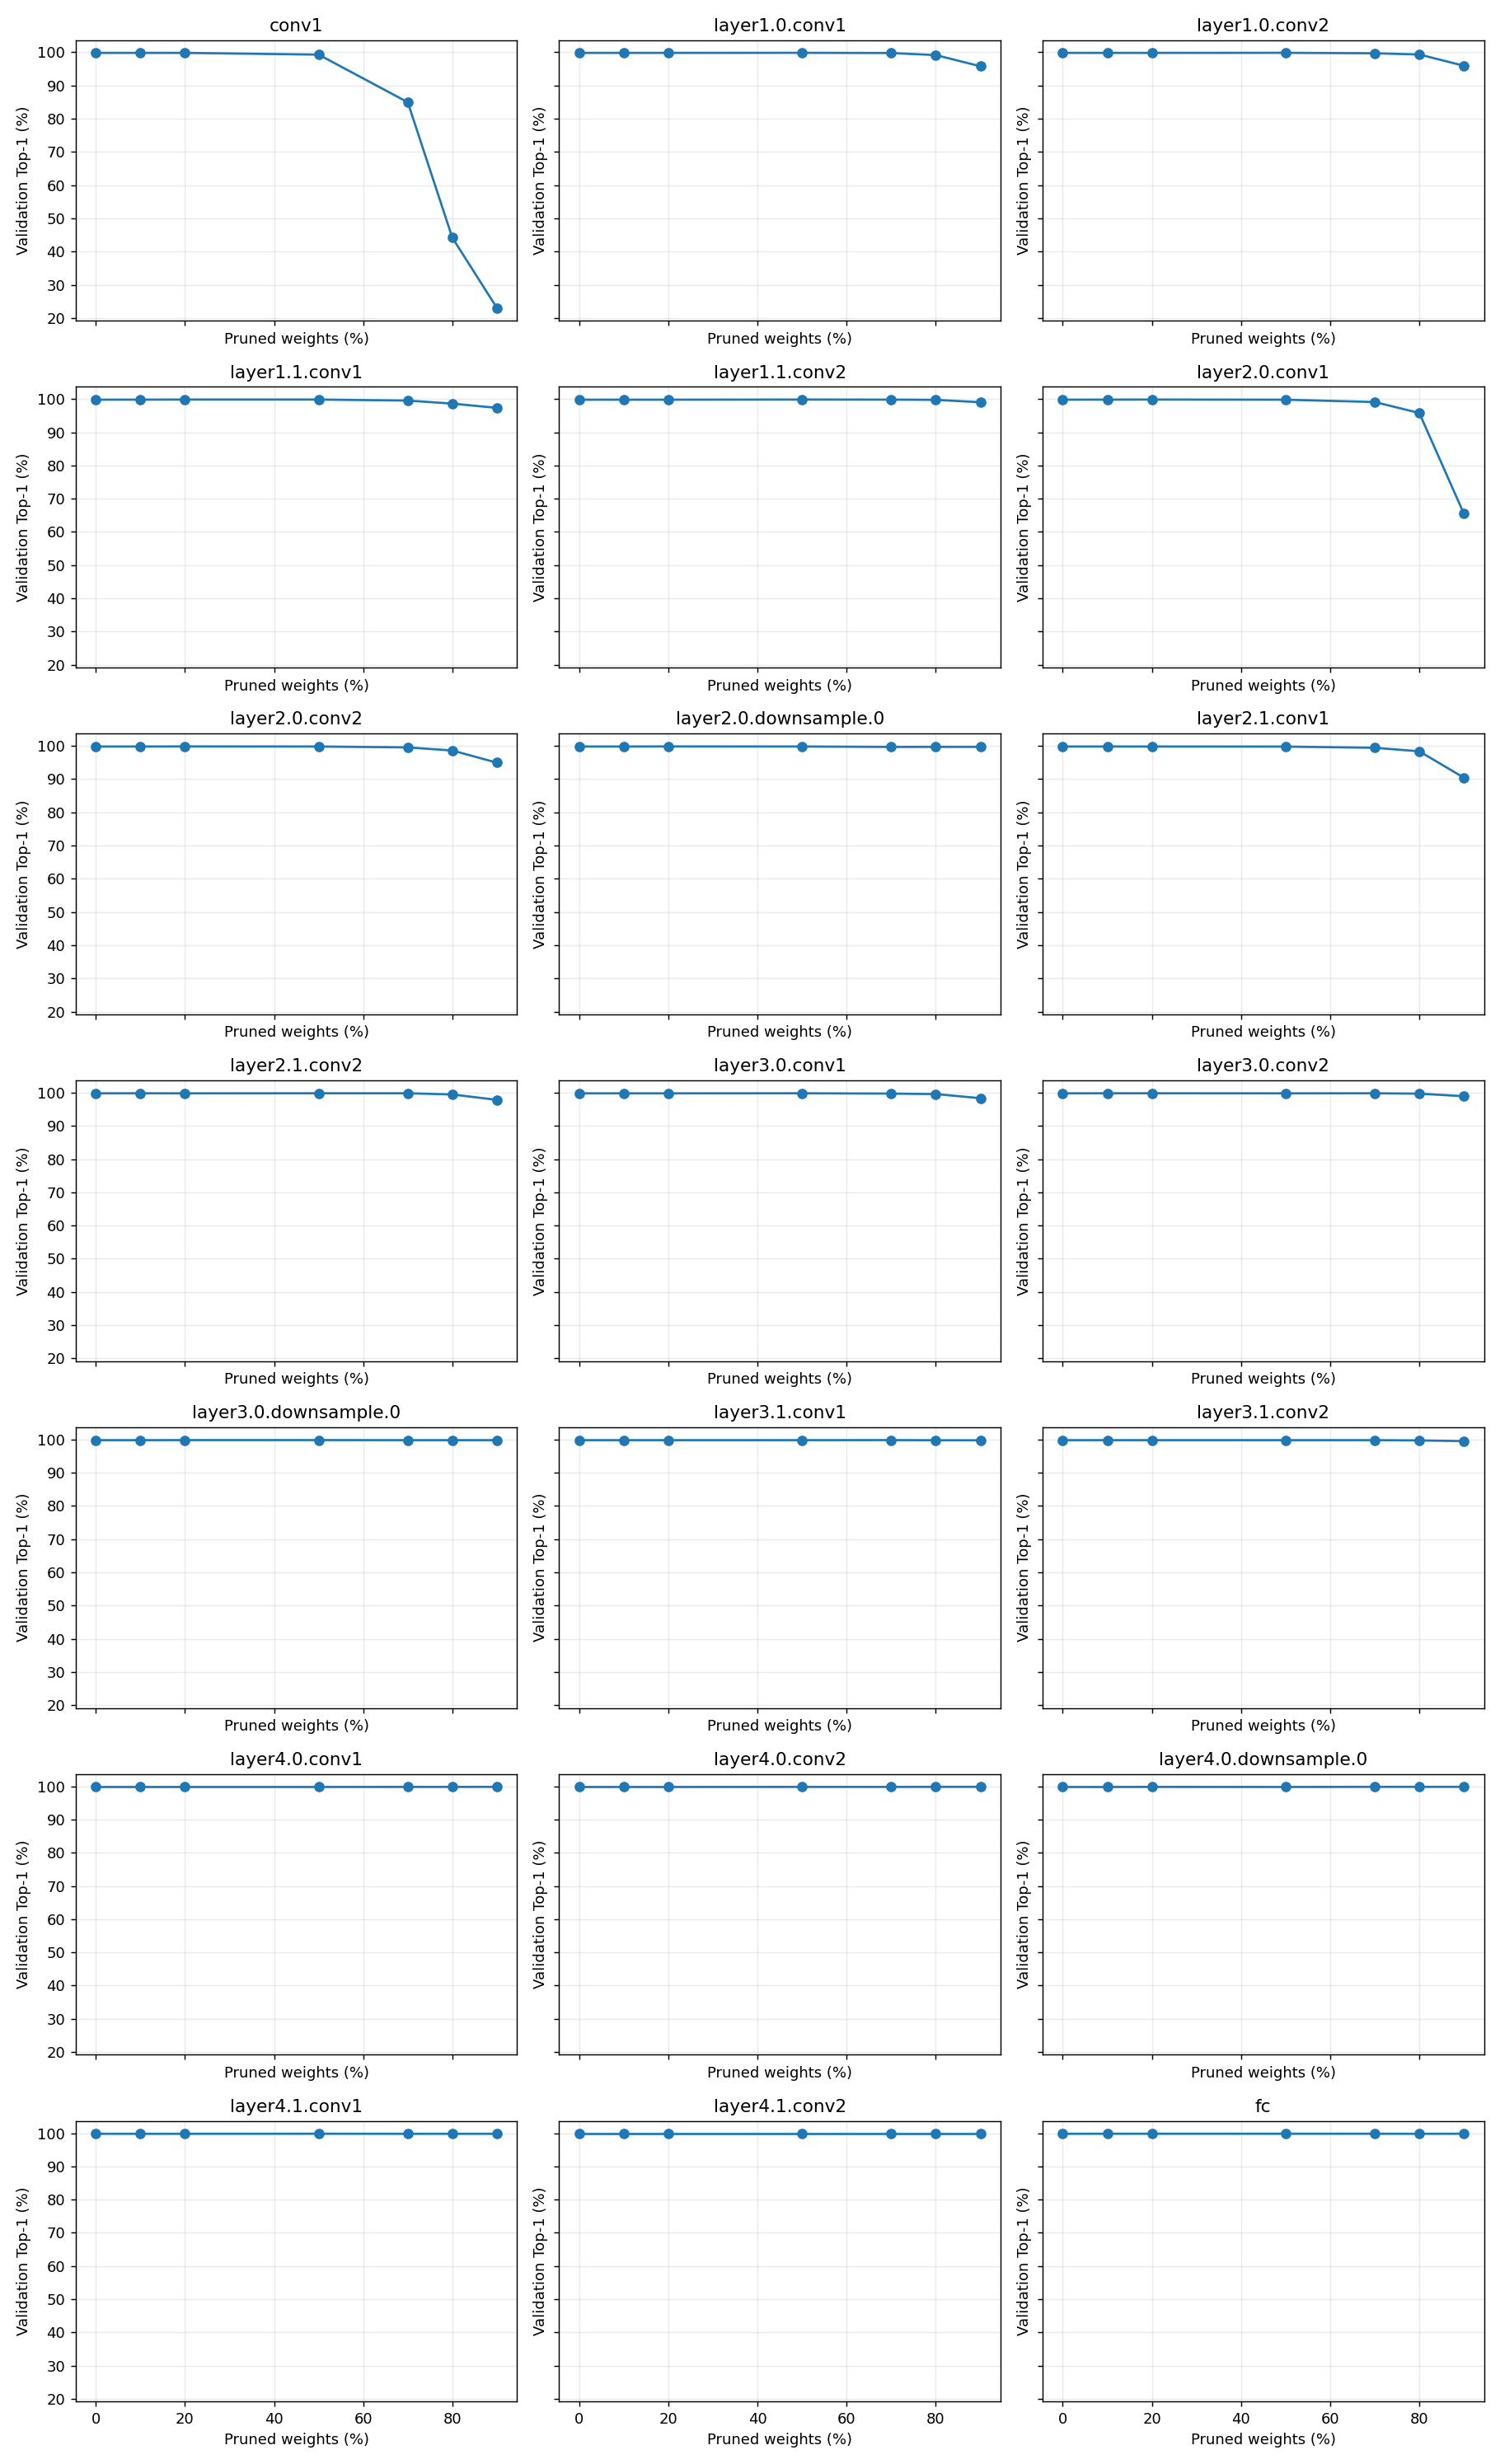

In [ ]:
display(Image(filename=str(ROOT / "figures" / "sensitivity.png")))


### 2. Local allocation and 3. Global allocation

For layer $\ell$, let $d_\ell=\max(0,a_{\ell,0}-a_{\ell,0.7})$ in percentage points. The local allocation uses

$$q_\ell=\frac{1}{1+d_\ell/5}, \qquad s_\ell=\operatorname{clip}(\alpha q_\ell,0.05,0.90).$$

A scalar water-filling search chooses $\alpha$ so the parameter-weighted average is 70%. Integer counts use largest-remainder rounding to reach exactly the requested total. Sensitive layers consequently receive a lower pruning fraction. Each layer removes its smallest absolute weights. Global pruning ranks the concatenated absolute weights, removes the same exact total, and lets the individual layer fractions emerge. Stable flattened-index ordering breaks threshold ties deterministically. The global method therefore has one shared magnitude cutoff, apart from deterministic handling of equal values at that cutoff.

| Layer                 |   Weights |   Local mask % |   Local actual zero % |   Global mask % |   Global actual zero % |
|:----------------------|----------:|---------------:|----------------------:|----------------:|-----------------------:|
| conv1                 |      1728 |        17.7083 |               17.7083 |         14.8727 |                14.8727 |
| layer1.0.conv1        |     36864 |        69.6696 |               69.6696 |         22.0215 |                22.0215 |
| layer1.0.conv2        |     36864 |        68.5791 |               68.5791 |          6.1252 |                 6.1252 |
| layer1.1.conv1        |     36864 |        66.7535 |               66.7535 |          6.7220 |                 6.7220 |
| layer1.1.conv2        |     36864 |        70.2257 |               70.2257 |          7.6253 |                 7.6253 |
| layer2.0.conv1        |     73728 |        61.6007 |               61.6007 |          6.4887 |                 6.4887 |
| layer2.0.conv2        |    147456 |        66.7542 |               66.7542 |          6.9722 |                 6.9722 |
| layer2.0.downsample.0 |      8192 |        68.5791 |               68.5791 |          4.2969 |                 4.2969 |
| layer2.1.conv1        |    147456 |        65.2656 |               65.2656 |          8.0526 |                 8.0526 |
| layer2.1.conv2        |    147456 |        70.2257 |               70.2257 |         10.2098 |                10.2098 |
| layer3.0.conv1        |    294912 |        69.1196 |               69.1196 |         11.4655 |                11.4655 |
| layer3.0.conv2        |    589824 |        70.2255 |               70.2255 |         17.9923 |                17.9923 |
| layer3.0.downsample.0 |     32768 |        70.2271 |               70.2271 |         11.7035 |                11.7035 |
| layer3.1.conv1        |    589824 |        70.2255 |               70.2255 |         29.6738 |                29.6738 |
| layer3.1.conv2        |    589824 |        70.2255 |               70.2255 |         44.3402 |                44.3402 |
| layer4.0.conv1        |   1179648 |        70.2256 |               70.2256 |         70.2994 |                70.2994 |
| layer4.0.conv2        |   2359296 |        70.2256 |               70.2256 |         82.3419 |                82.3419 |
| layer4.0.downsample.0 |    131072 |        70.2255 |               70.2255 |         17.4156 |                17.4156 |
| layer4.1.conv1        |   2359296 |        70.2256 |               70.2256 |         96.9073 |                96.9073 |
| layer4.1.conv2        |   2359296 |        70.2256 |               70.2256 |         88.8113 |                88.8113 |
| fc                    |      5120 |        70.2344 |               70.2344 |          0.0391 |                 0.0391 |

Global pruning removed the largest fraction in `layer4.1.conv1` (96.91%) and the smallest fraction in `fc` (0.04%). No layer was completely removed. This is a usable distribution because it preserves a nonempty path through every eligible layer and supports the measured recovery below. It is not a sensitivity guarantee: magnitude scales differ between layers and interact with normalization, so small absolute values alone do not prove low functional importance.


### 4. Fine-tuning and 5. Mask verification

Both methods use SGD with Nesterov momentum 0.9, weight decay 0.0005, initial learning rate 0.01, 12 epochs, and cosine decay to 0.0001. Batch size, seed, batch order, and augmentations are identical. Masks remain fixed. Gradients and momentum buffers are also masked; after every optimizer step, $W \leftarrow M\odot W$ is enforced. Assertions check every masked coordinate, and the final layer table compares actual zeros with mask zeros. Extra natural zeros, if present, are recorded separately instead of being mistaken for an additional pruning decision.

| Method           |   Before pruning test % |   After pruning test % |   After FT test % |   Recovered (pp) |   Final drop (pp) |
|:-----------------|------------------------:|-----------------------:|------------------:|-----------------:|------------------:|
| Local magnitude  |                 93.0700 |                88.0700 |           91.9700 |           3.9000 |            1.1000 |
| Global magnitude |                 93.0700 |                93.0000 |           90.9300 |          -2.0700 |            2.1400 |

For global magnitude, fine-tuning reduced test accuracy by 2.07 percentage points relative to the immediate pruned checkpoint. Thus it did not recover accuracy in this case. The curves show the disruption and subsequent partial recovery under the shared learning-rate schedule. Updates to weights and BatchNorm statistics under augmentation can move an already accurate pretrained solution away from its useful operating point; the experiment does not isolate which factor caused the decrease. A smaller learning rate or longer schedule could be investigated on validation data, but the fixed protocol is retained here for a fair local/global comparison.


Local magnitude: training and validation loss and accuracy.


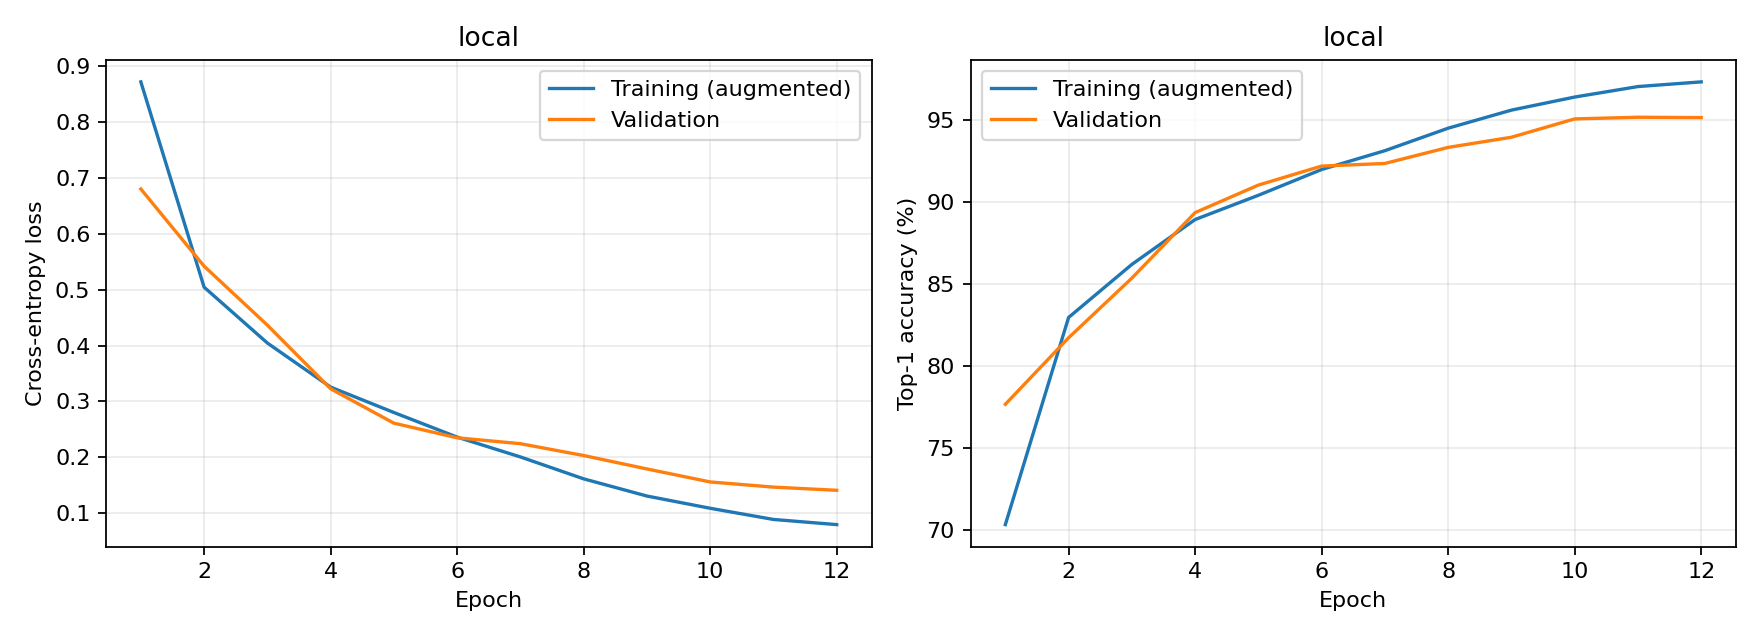

In [ ]:
display(Image(filename=str(ROOT / "figures" / "local_curves.png")))


Global magnitude: training and validation loss and accuracy.


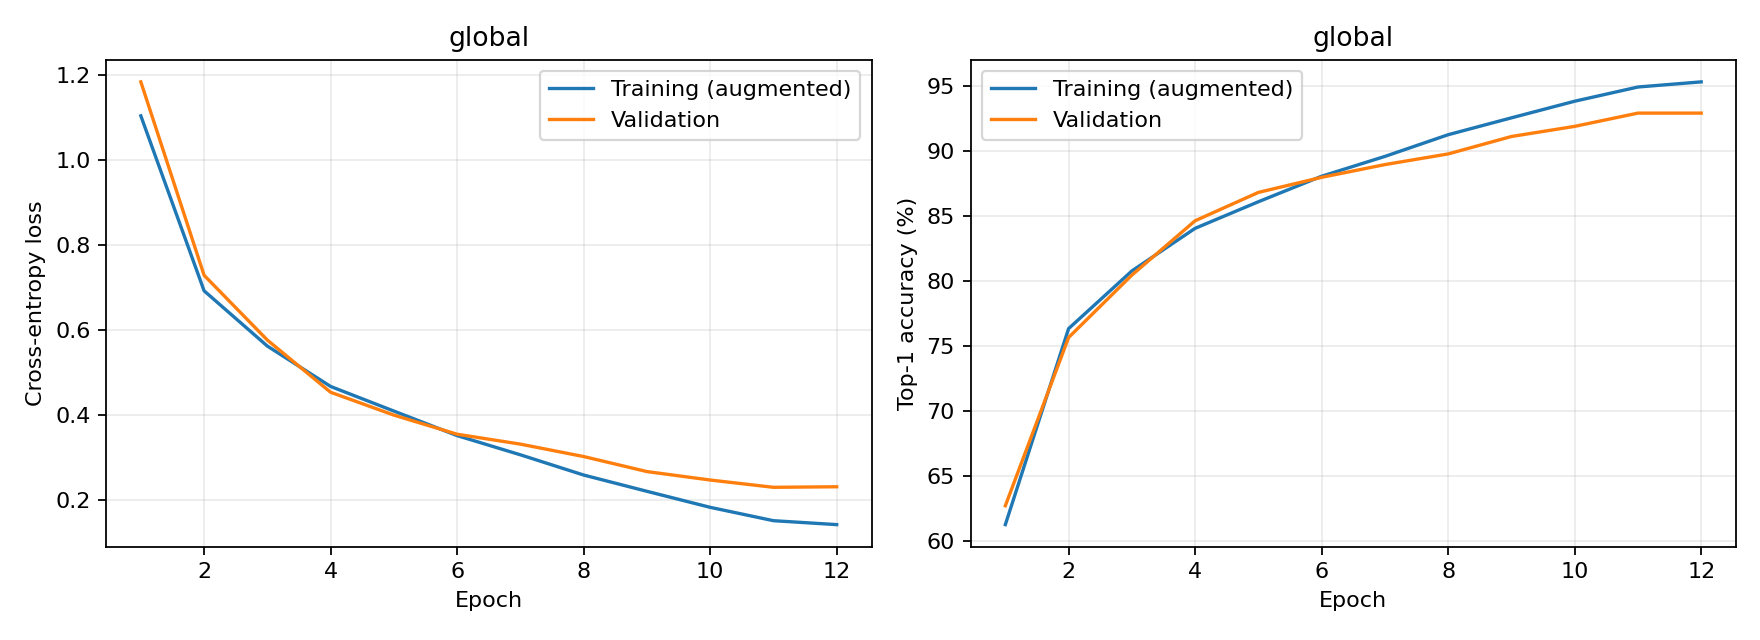

In [ ]:
display(Image(filename=str(ROOT / "figures" / "global_curves.png")))


### 6. COO storage and 7. COO inference

Each pruned tensor is converted with `to_sparse().coalesce()`. The saved file contains float32 nonzero values, int64 COO indices, original shapes, Boolean pruning masks, and unpruned state tensors. A load-and-reconstruct check verifies exact equality for every pruned tensor. COO convolutions explicitly call `to_dense()` during every forward because ordinary PyTorch Conv2d does not execute general sparse COO convolution. The final linear layer uses `torch.sparse.mm`. Output agreement with the dense masked representation is asserted before profiling, and full evaluation is repeated for COO execution.

| Model                   |   Test Top-1 % |   Train Top-1 % |   Test Top-5 % |   Train Top-5 % |   Test macro-F1 |   Train macro-F1 |   Latency ms |   Peak GPU MB |   Average GPU MB |   GPU J/batch | CPU J/batch   |
|:------------------------|---------------:|----------------:|---------------:|----------------:|----------------:|-----------------:|-------------:|--------------:|-----------------:|--------------:|:--------------|
| Local magnitude COO     |        91.9700 |         98.1820 |        99.6900 |         99.9800 |          0.9196 |           0.9818 |      13.5093 |      417.6543 |         345.6020 |        0.9117 | N/A           |
| Global magnitude COO    |        90.9300 |         96.4960 |        99.7300 |         99.9260 |          0.9092 |           0.9649 |      13.0739 |      418.8339 |         345.2503 |        0.8958 | N/A           |
| Iterative magnitude COO |        90.5900 |         98.3560 |        99.6600 |         99.9700 |          0.9058 |           0.9835 |      13.0901 |      417.4454 |         344.7547 |        0.8893 | N/A           |
| Iterative GraSP COO     |        88.5500 |         96.2300 |        99.5200 |         99.9240 |          0.8849 |           0.9622 |      13.0375 |      416.7086 |         344.6733 |        0.8828 | N/A           |

For a four-dimensional convolution tensor, an entry uses approximately 4 bytes for its value and 4 x 8 bytes for its indices. At 70% sparsity, values and indices alone therefore cost about $0.3(4+32)=10.8$ bytes per original weight, versus 4 bytes in dense FP32; a stored Boolean mask adds about one more byte per original weight. The break-even sparsity is above $1-4/36=88.89\%$ even before masks and serialization overhead. Consequently a 70% sparse, four-coordinate COO file can be larger than its dense file. The measured file sizes include that overhead. A flattened two-dimensional encoding, compressed indices, or a hardware-supported format would have different storage costs, but none is substituted silently here.

Local magnitude: the dense state is 44.771 MB and the actual COO package is 131.840 MB, a size ratio of 2.94. Dense masked latency is 12.473 ms per batch versus 13.509 ms for the COO execution path.

Global magnitude: the dense state is 44.771 MB and the actual COO package is 131.783 MB, a size ratio of 2.94. Dense masked latency is 12.392 ms per batch versus 13.074 ms for the COO execution path.

Zero-valued weights do not reduce dense tensor dimensions, kernel launches, or the dense convolution loop bounds. The GPU executes the same dense kernels and nominal MAC count. COO-to-dense conversion adds reconstruction and allocation work, so sparse storage by itself is not an inference acceleration. Actual sparse speedups depend on kernel support, sparsity structure, batch size, and the cost of indexing and data movement.


## Task 2: Saliency-based iterative pruning

Both methods start from the same random initialization and warm-up state. The GraSP implementation uses two autograd passes to calculate a Hessian-vector product. It never constructs the model Hessian. `gsum` is the sample-weighted calibration gradient, and `hv` is its Hessian-vector product. The signed score is minus the weight times its HVP entry; the largest scores are removed.


#### Calculate signed GraSP scores


In [ ]:
def grasp_scores(model, masks):
    """Compute signed GraSP scores using two autograd passes, without forming a Hessian.

    gsum is the sample-weighted mean loss gradient; hv is its Hessian-vector
    product. The score is minus the weight times the corresponding HVP entry.
    Temperature, calibration weighting, BatchNorm mode, and ranking are unchanged.
    """
    model.eval()  # Fixed BatchNorm statistics; avoids changing state during criterion.
    params = list(model.parameters())
    total = sum(len(y) for x, y in CALIB.batches())
    gsum = [torch.zeros_like(p) for p in params]
    for x, y in CALIB.batches():
        loss = F.cross_entropy(model(x) / 200.0, y)
        grads = torch.autograd.grad(loss, params)
        for acc, g in zip(gsum, grads):
            acc.add_(g.detach(), alpha=len(y) / total)
    # In later stages the effective parameter is M*theta. Dead coordinates do
    # not contribute to the gradient norm or the HVP direction.
    mask_lookup = {id(m.weight): masks[n] for n, m in eligible(model).items()}
    for p, g in zip(params, gsum):
        if id(p) in mask_lookup:
            g.mul_(mask_lookup[id(p)])
    hv = [torch.zeros_like(p) for p in params]
    for x, y in CALIB.batches():
        loss = F.cross_entropy(model(x) / 200.0, y)
        grads = torch.autograd.grad(loss, params, create_graph=True)
        dot = sum((g * v).sum() for g, v in zip(grads, gsum))
        hs = torch.autograd.grad(dot, params)
        for acc, h in zip(hv, hs):
            acc.add_(h.detach(), alpha=len(y) / total)
    lookup = {id(p): h for p, h in zip(params, hv)}
    scores = {
        n: -m.weight.detach() * lookup[id(m.weight)] for n, m in eligible(model).items()
    }
    assert all(torch.isfinite(v).all() for v in scores.values())
    return scores


#### Check the Hessian-vector product and ranking


In [ ]:
def verify_grasp_math():
    """Check the HVP on a small analytical example and verify signed-score ranking.

    The model Hessian is never constructed; only this small check uses one.
    """
    theta = torch.tensor([0.4, -0.7, 0.2], dtype=torch.float64, requires_grad=True)

    def loss(t):
        return (t.sin().sum()) ** 2 + 0.3 * (t * t).sum()

    g = torch.autograd.grad(loss(theta), theta, create_graph=True)[0]
    hg = torch.autograd.grad((g * g.detach()).sum(), theta)[0]
    explicit = torch.autograd.functional.hessian(loss, theta) @ g.detach()
    torch.testing.assert_close(hg, explicit)
    # Signed scores: -3 survives while +4 is removed. No absolute value.
    test = torch.tensor([-3.0, -0.5, 1.0, 4.0])
    removed = torch.argsort(test, descending=True)[:2]
    assert set(removed.tolist()) == {2, 3}
    result = {
        "hvp_matches_toy_hessian": True,
        "largest_signed_scores_removed": True,
        "max_hvp_error": float((hg - explicit).abs().max()),
    }
    save_json("grasp_verification.json", result)
    print(result, flush=True)


#### Run the two iterative pruning methods


In [ ]:
def task2():
    """Compare iterative magnitude and GraSP from a common random initialization.

    Save a shared warm-up state, then run each method for the same total budget.
    Masks accumulate at the recorded 20/40/60 percent accuracy thresholds,
    with the original epoch-granularity behavior and fallback deadlines.
    """
    verify_grasp_math()
    seed_all()
    model = fresh()
    initial = cpu_state(model)
    torch.save(initial, ROOT / "checkpoints" / "random_initial.pt")
    optimizer = optimizer_for(model, 0.1)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, SCRATCH_EPOCHS, eta_min=0.001
    )
    warm_history = []
    for epoch in range(5):
        row = train_epoch(model, optimizer, epoch)
        val = evaluate(model, VALID)
        row.update(
            epoch=epoch + 1,
            lr=optimizer.param_groups[0]["lr"],
            val_loss=val["loss"],
            val_top1=val["top1"],
        )
        warm_history.append(row)
        scheduler.step()
        print("Warm-up", row, flush=True)
        if val["top1"] >= 20:
            break
    warm = cpu_state(model)
    warm_opt = copy.deepcopy(optimizer.state_dict())
    warm_sched = copy.deepcopy(scheduler.state_dict())
    torch.save(
        {
            "initial": initial,
            "state": warm,
            "optimizer": warm_opt,
            "scheduler": warm_sched,
            "history": warm_history,
        },
        ROOT / "checkpoints" / "warmup.pt",
    )
    curves(warm_history, "warmup")
    del model, optimizer, scheduler
    stages = []
    results = {}
    for method in ["iterative_magnitude", "iterative_grasp"]:
        seed_all()
        model = fresh(warm)
        masks = masks_for(model)
        assert all(torch.equal(v.cpu(), warm[k]) for k, v in model.state_dict().items())
        optimizer = optimizer_for(model, 0.1)
        optimizer.load_state_dict(copy.deepcopy(warm_opt))
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, SCRATCH_EPOCHS, eta_min=0.001
        )
        scheduler.load_state_dict(copy.deepcopy(warm_sched))
        history = copy.deepcopy(warm_history)
        stage = 0
        val = evaluate(model, VALID)
        for epoch in range(len(warm_history), SCRATCH_EPOCHS):
            thresholds = [20, 40, 60]
            deadlines = [5, 12, 25]
            if stage < 3 and (
                val["top1"] >= thresholds[stage] or epoch >= deadlines[stage]
            ):
                before = evaluate(model, VALID)
                before_test = evaluate(model, TEST)
                old = {k: v.clone() for k, v in masks.items()}
                torch.cuda.synchronize()
                start = time.perf_counter()
                scores = (
                    grasp_scores(model, masks) if method == "iterative_grasp" else None
                )
                torch.cuda.synchronize()
                criterion_seconds = time.perf_counter() - start
                # Magnitude criterion timing includes explicitly computing absolute values.
                if scores is None:
                    start = time.perf_counter()
                    scores = {
                        n: m.weight.detach().abs() for n, m in eligible(model).items()
                    }
                    torch.cuda.synchronize()
                    criterion_seconds = time.perf_counter() - start
                stage_target = TARGET * [0.5, 0.75, 1][stage]
                masks = prune_global(
                    model,
                    masks,
                    stage_target,
                    scores,
                    largest=method == "iterative_grasp",
                )
                apply_masks(model, masks, optimizer)
                assert all(not bool((masks[n] & ~old[n]).any()) for n in masks)
                after = evaluate(model, VALID)
                after_test = evaluate(model, TEST)
                row = {
                    "method": method,
                    "stage": stage + 1,
                    "epoch_before_training": epoch + 1,
                    "target": stage_target,
                    "before_val_top1": before["top1"],
                    "after_val_top1": after["top1"],
                    "before_test_top1": before_test["top1"],
                    "after_test_top1": after_test["top1"],
                    "sparsity": sum(int((~v).sum()) for v in masks.values())
                    / sum(v.numel() for v in masks.values()),
                    "criterion_seconds": criterion_seconds,
                    "trigger": (
                        "accuracy"
                        if before["top1"] >= thresholds[stage]
                        else "budget deadline"
                    ),
                    "collapsed_layers": [n for n, v in masks.items() if not v.any()],
                }
                stages.append(row)
                stage += 1
                print("PRUNING", row, flush=True)
                save_json("iterative_stages.json", stages)
                del scores, old
            start = time.perf_counter()
            lr = optimizer.param_groups[0]["lr"]
            row = train_epoch(model, optimizer, epoch, masks)
            val = evaluate(model, VALID)
            row.update(
                epoch=epoch + 1,
                lr=lr,
                val_loss=val["loss"],
                val_top1=val["top1"],
                seconds=time.perf_counter() - start,
            )
            history.append(row)
            scheduler.step()
            curves(history, method)
            torch.save(
                {
                    "state": cpu_state(model),
                    "optimizer": optimizer.state_dict(),
                    "scheduler": scheduler.state_dict(),
                    "history": history,
                    "masks": {n: v.cpu() for n, v in masks.items()},
                    "stage": stage,
                    "epoch": epoch + 1,
                },
                ROOT / "checkpoints" / f"{method}_resume.pt",
            )
            print(method, row, flush=True)
        assert stage == 3
        results[method] = assess(model, method, masks)
        del model, masks, optimizer, scheduler
        gc.collect()
        torch.cuda.empty_cache()
    return results


In [ ]:
iterative_results = task2()


{'hvp_matches_toy_hessian': True, 'largest_signed_scores_removed': True, 'max_hvp_error': 1.1102230246251565e-16}
Warm-up {'train_loss': 2.196664269955953, 'train_top1': 21.66, 'epoch': 1, 'lr': 0.1, 'val_loss': 1.7296920204162598, 'val_top1': 32.96}
PRUNING {'method': 'iterative_magnitude', 'stage': 1, 'epoch_before_training': 2, 'target': 0.35, 'before_val_top1': 32.96, 'after_val_top1': 33.0, 'before_test_top1': 32.4, 'after_test_top1': 32.5, 'sparsity': 0.34999998208583893, 'criterion_seconds': 0.0006431019999126875, 'trigger': 'accuracy', 'collapsed_layers': []}
iterative_magnitude {'train_loss': 1.574633651140001, 'train_top1': 40.913333333333334, 'epoch': 2, 'lr': 0.09990232305719944, 'val_loss': 1.4254144985198975, 'val_top1': 50.56, 'seconds': 18.802132647999997}
PRUNING {'method': 'iterative_magnitude', 'stage': 2, 'epoch_before_training': 3, 'target': 0.5249999999999999, 'before_val_top1': 50.56, 'after_val_top1': 49.64, 'before_test_top1': 49.75, 'after_test_top1': 48.79, '

### Results and discussion


### 1. Shared random initialization and warm-up

The model is created with `resnet18(pretrained=False)` and does not load the pretrained checkpoint. Its initial state is saved. One shared warm-up ran for 1 epoch(s) and reached 32.96% validation Top-1. Both methods restore byte-equal copies of this state, optimizer momentum, and scheduler position. The warm-up checkpoint contains the initial weights, warm-up weights, optimizer state, and curves. Each method receives 50 total training epochs including the shared warm-up; SGD uses initial learning rate 0.1, Nesterov momentum 0.9, weight decay 0.0005, and cosine decay to 0.001. This is a fixed-budget comparison, not a claim of full convergence.


Shared random-initialization warm-up.


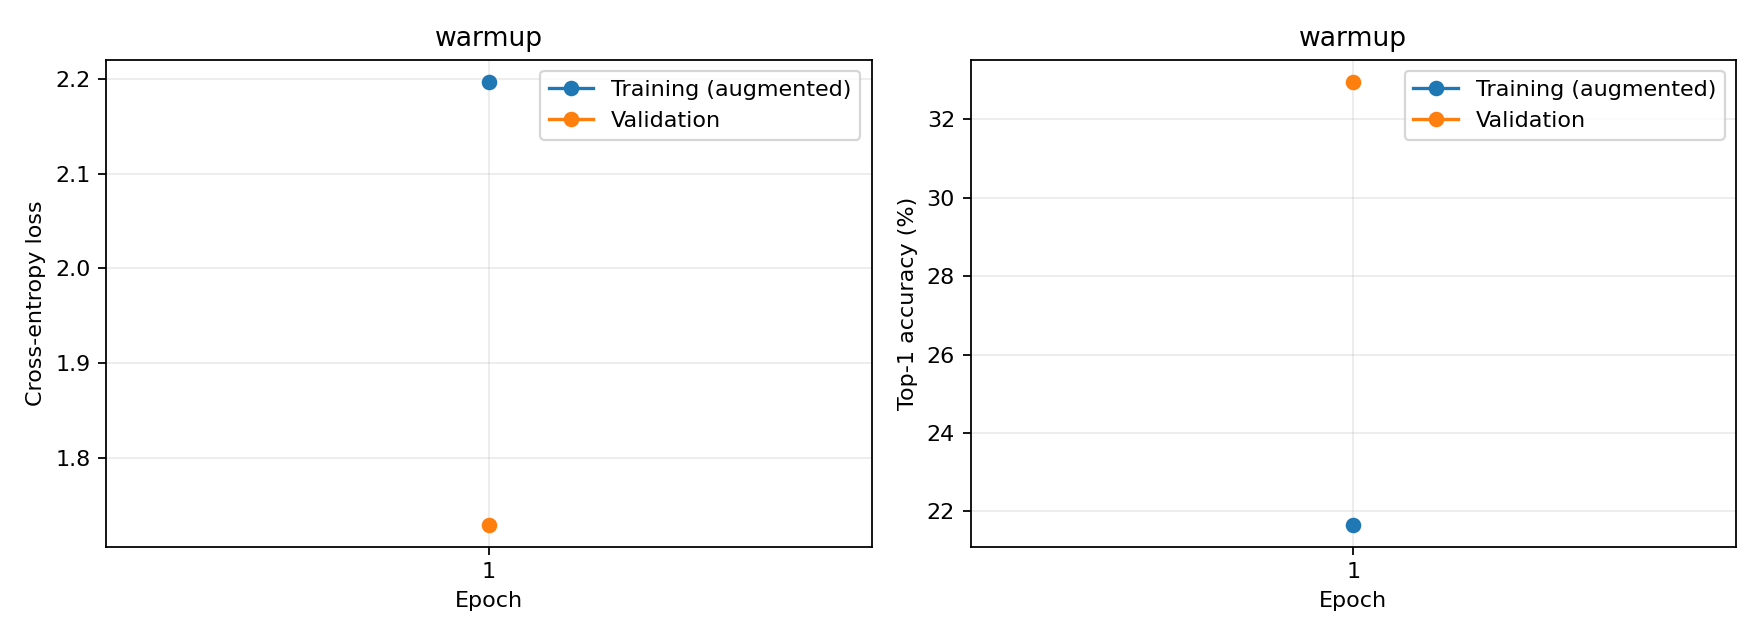

In [ ]:
display(Image(filename=str(ROOT / "figures" / "warmup_curves.png")))


### 2. Calibration and 3. GraSP criterion

Calibration uses 200 normalization-only optimization images, 20 per class. With batch size 128, there are two batches of 128 and 72 images. Batch means are weighted by their sample counts. BatchNorm statistics are fixed during criterion computation. A temperature of 200 follows the GraSP implementation convention and is used for scoring only; optimization uses ordinary cross-entropy without temperature scaling.

$$L(\theta)=\sum_b\frac{n_b}{200}L_b(\theta),\quad g=\nabla L,\quad Hg=\nabla_\theta\left[(\nabla L)^T\operatorname{stopgrad}(g)\right],\quad S_i=-\theta_i(Hg)_i.$$

One pass accumulates the detached mean gradient. A second pass accumulates Hessian-vector products with that common vector. This retains cross-batch terms, unlike averaging independent $H_bg_b$ products. Pruned coordinates are removed from the gradient-norm direction in later stages. Bias and normalization parameters participate in the loss derivatives but are never candidates for pruning. Autograd computes the HVP without materializing a model Hessian. A three-parameter toy test compares the HVP against an explicit Hessian solely as a numerical unit check; no network Hessian is constructed.

The signed GraSP ranking removes the **largest** $S_i$ values. It does not remove the smallest values and does not take absolute values. For a deletion $\Delta\theta_i=-\theta_i$, the first-order change in squared gradient norm is $2g^TH\Delta\theta=-2\theta_i(Hg)_i=2S_i$. Preserving or increasing gradient flow therefore favors removing large scores under this convention. The direction is verified with a known signed-score example. This derivation also explains why an implementation that merely copies the magnitude-pruning sorting direction is wrong.


### 4. Three stages and 5. Cumulative masks

The cumulative sparsities are 35%, 52.5%, and 70%, corresponding to $0.50s^\star$, $0.75s^\star$, and $s^\star$. Stages trigger after epoch-level validation accuracy first reaches approximately 20%, 40%, and 60%; they can overshoot because validation is checked once per epoch. To guarantee the complete sparsity schedule within the fixed budget, fallback epoch deadlines are 5, 12, and 25 completed epochs. The table identifies the actual trigger; a deadline is not presented as reaching an accuracy threshold. Only currently retained weights can be removed, so the new mask is a subset of the old mask. The code asserts no regrowth and reapplies masks, including momentum masking, after every update.

| Method              |   Stage |   Next epoch |   Before val % |   After val % |   Before test % |   After test % |   Sparsity % |   Criterion seconds | Trigger   | Collapsed layers   |
|:--------------------|--------:|-------------:|---------------:|--------------:|----------------:|---------------:|-------------:|--------------------:|:----------|:-------------------|
| Iterative magnitude |       1 |            2 |        32.9600 |       33.0000 |         32.4000 |        32.5000 |      35.0000 |              0.0006 | accuracy  | None               |
| Iterative magnitude |       2 |            3 |        50.5600 |       49.6400 |         49.7500 |        48.7900 |      52.5000 |              0.0007 | accuracy  | None               |
| Iterative magnitude |       3 |            5 |        60.0400 |       59.5400 |         59.6100 |        59.4200 |      70.0000 |              0.0006 | accuracy  | None               |
| Iterative GraSP     |       1 |            2 |        32.9600 |       10.0000 |         32.4000 |        10.0000 |      35.0000 |              0.4689 | accuracy  | None               |
| Iterative GraSP     |       2 |            4 |        42.1600 |       10.0000 |         41.9600 |        10.0000 |      52.5000 |              0.3521 | accuracy  | None               |
| Iterative GraSP     |       3 |            8 |        61.3200 |       10.0000 |         59.3100 |        10.0000 |      70.0000 |              0.3524 | accuracy  | None               |

Criterion time is synchronized wall time for score construction. It excludes the subsequent common sorting and mask-application operation, which is why it should not be read as total pruning time. Test accuracies immediately before and after stages are recorded for the requested comparison; stage decisions use validation accuracy only.


### 6. Final remaining weights and model profiles

| Layer                 |   Local remaining |   Global remaining |   Iterative magnitude remaining |   Iterative GraSP remaining |
|:----------------------|------------------:|-------------------:|--------------------------------:|----------------------------:|
| conv1                 |            0.8229 |             0.8513 |                          0.8970 |                      0.1366 |
| layer1.0.conv1        |            0.3033 |             0.7798 |                          0.7302 |                      0.1576 |
| layer1.0.conv2        |            0.3142 |             0.9387 |                          0.7043 |                      0.1959 |
| layer1.1.conv1        |            0.3325 |             0.9328 |                          0.6903 |                      0.1648 |
| layer1.1.conv2        |            0.2977 |             0.9237 |                          0.6751 |                      0.2054 |
| layer2.0.conv1        |            0.3840 |             0.9351 |                          0.5688 |                      0.3091 |
| layer2.0.conv2        |            0.3325 |             0.9303 |                          0.5335 |                      0.3142 |
| layer2.0.downsample.0 |            0.3142 |             0.9570 |                          0.7712 |                      0.2607 |
| layer2.1.conv1        |            0.3473 |             0.9195 |                          0.5312 |                      0.3013 |
| layer2.1.conv2        |            0.2977 |             0.8979 |                          0.5309 |                      0.2593 |
| layer3.0.conv1        |            0.3088 |             0.8853 |                          0.4066 |                      0.2818 |
| layer3.0.conv2        |            0.2977 |             0.8201 |                          0.4006 |                      0.2690 |
| layer3.0.downsample.0 |            0.2977 |             0.8830 |                          0.7274 |                      0.2595 |
| layer3.1.conv1        |            0.2977 |             0.7033 |                          0.4067 |                      0.2721 |
| layer3.1.conv2        |            0.2977 |             0.5566 |                          0.4100 |                      0.2369 |
| layer4.0.conv1        |            0.2977 |             0.2970 |                          0.2511 |                      0.2267 |
| layer4.0.conv2        |            0.2977 |             0.1766 |                          0.2452 |                      0.3383 |
| layer4.0.downsample.0 |            0.2977 |             0.8258 |                          0.6786 |                      0.1758 |
| layer4.1.conv1        |            0.2977 |             0.0309 |                          0.2368 |                      0.2790 |
| layer4.1.conv2        |            0.2977 |             0.1119 |                          0.2429 |                      0.3687 |
| fc                    |            0.2977 |             0.9996 |                          0.7314 |                      0.2355 |


Layer-wise remaining-weight ratios for all unstructured methods.


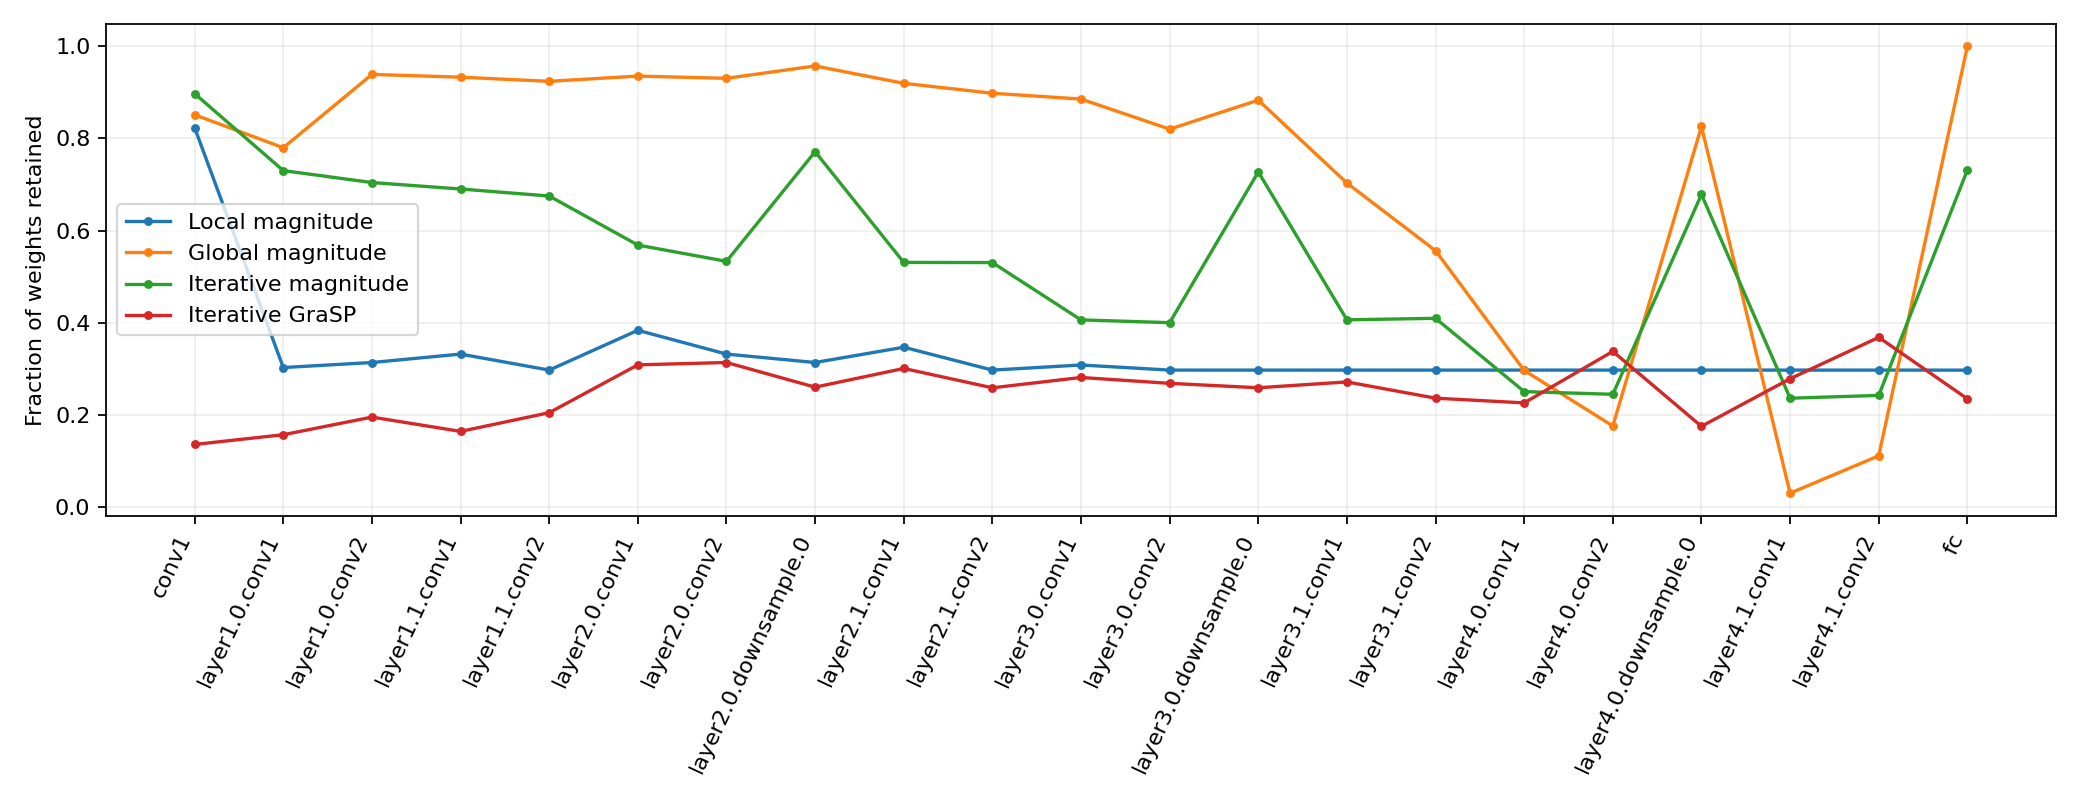

In [ ]:
display(Image(filename=str(ROOT / "figures" / "remaining_ratios.png")))


Iterative magnitude: full training budget including the common warm-up.


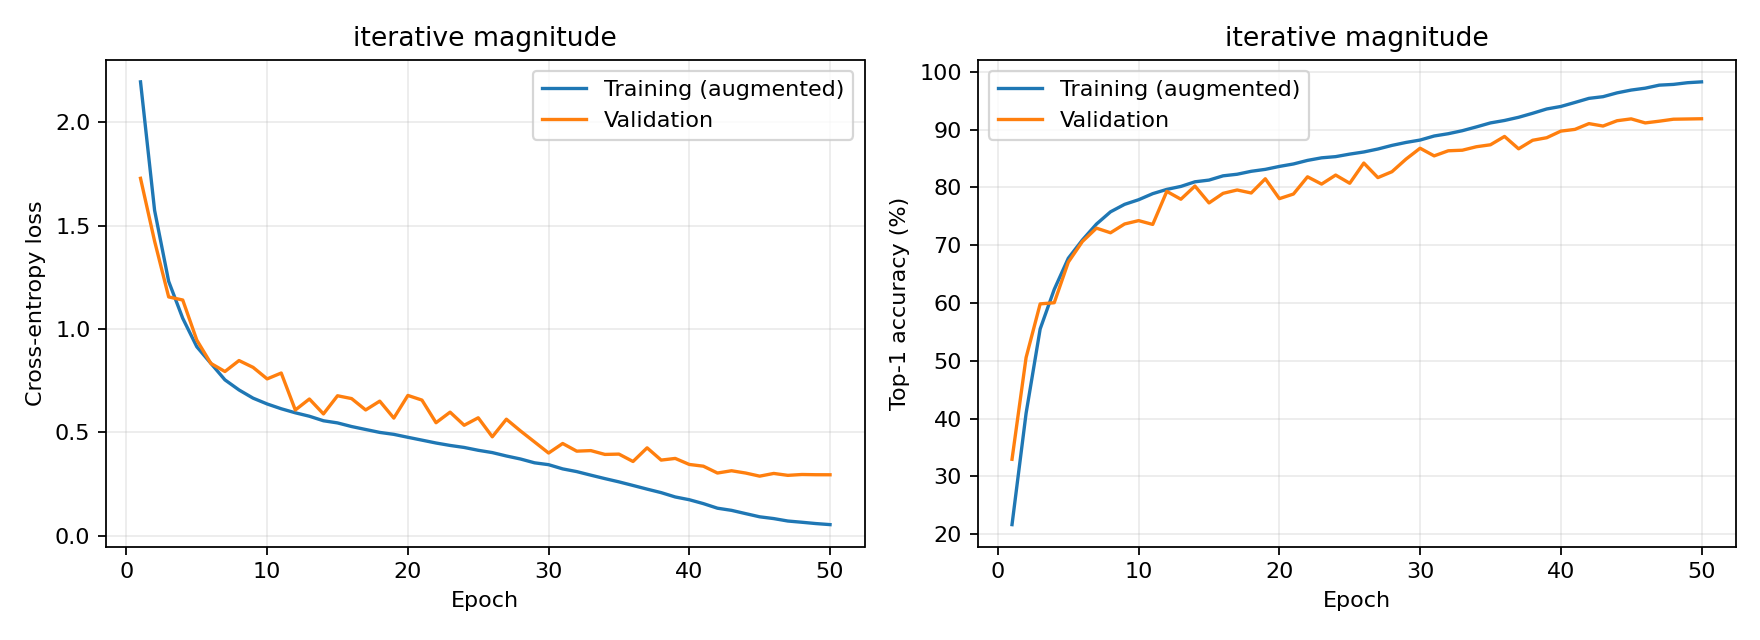

In [ ]:
display(Image(filename=str(ROOT / "figures" / "iterative_magnitude_curves.png")))


Iterative GraSP: full training budget including the common warm-up.


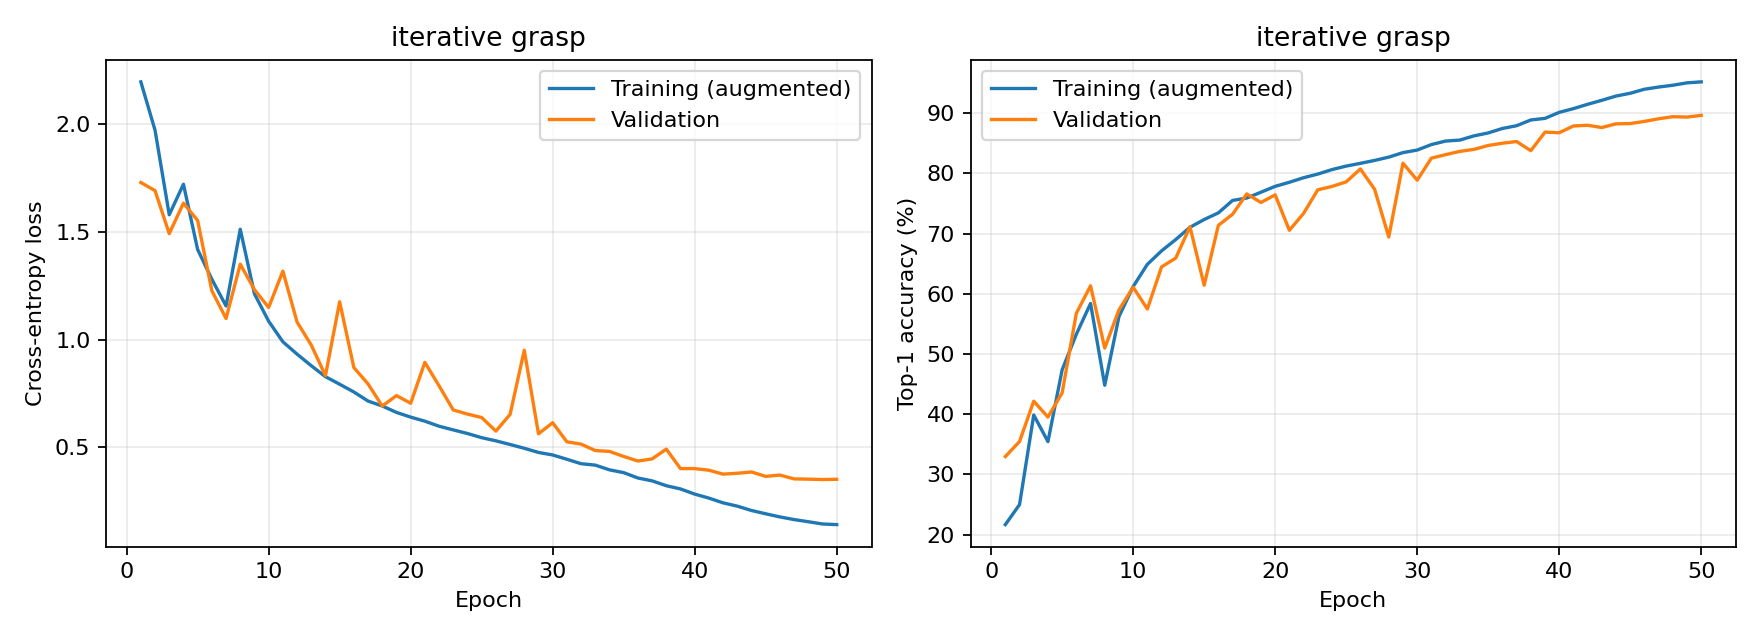

In [ ]:
display(Image(filename=str(ROOT / "figures" / "iterative_grasp_curves.png")))


### Required comparison

Iterative magnitude achieved 90.59% test Top-1, iterative GraSP achieved 88.55%, and pretrained global magnitude achieved 90.93%. GraSP minus iterative magnitude is -2.04 percentage points. Iterative magnitude minus pretrained global magnitude is -0.34 points. The first difference is a controlled comparison of the criterion under shared initialization and training budget. The second is descriptive only: Task 1 inherits a pretrained solution and unknown original training cost, whereas Task 2 must learn representations from scratch. It cannot isolate the benefit of iterative scheduling. A single seed also cannot establish statistical superiority.

Layer collapse observations: No eligible layer became completely pruned at any recorded stage.

GraSP caused a separate functional failure immediately after 3 pruning stage(s): test accuracy fell to approximately chance level even though no full layer was deleted. Thus 'no layer collapse' refers only to the structural mask check, not to preservation of useful predictions. The later learning curves demonstrate recovery with continued training. The Taylor score measures a local gradient-flow change, and removing a large fraction of weights at once can violate that local approximation; fixed pre-pruning BatchNorm statistics can also be poorly matched immediately after deletion. These are plausible mechanisms rather than experimentally isolated causes.

A saliency criterion can preserve a local gradient-flow property while still losing eventual classification accuracy. Its finite calibration subset, fixed BatchNorm statistics, temperature, higher-order numerical sensitivity, and threshold overshoot all affect the selected support. The criterion costs and learning curves show whether a measured benefit compensates for its extra computation. The final results use the same dense masked and COO inference procedure as Task 1.


## Task 3: Regression-based structured pruning

The model starts from the same pretrained checkpoint as Tasks 0 and 1. Each selected block's internal channels are reduced while its external residual dimensions remain aligned. `X` contains unfolded input patches, `Y` contains matched teacher outputs, `beta` contains LASSO channel coefficients, and `Xprime` is the reduced design matrix. Least squares reconstructs the smaller convolution's weights.


#### Choose internal channel widths


In [ ]:
def structured_plan(model):
    """Choose internal block widths that match the original overall removal target.

    Count both the preceding convolution's removed output filters and the
    next convolution's removed input filters. External residual widths stay fixed.
    """
    blocks = [
        (n, m)
        for n, m in model.named_modules()
        if hasattr(m, "conv2") and hasattr(m, "bn2")
    ][1:]
    total = sum(m.weight.numel() for m in eligible(model).values())

    def plan(retain):
        return {n: max(1, round(m.conv1.out_channels * retain)) for n, m in blocks}

    def removed(widths):
        return sum(
            (m.conv1.out_channels - widths[n])
            * (m.conv1.in_channels * 9 + m.conv2.out_channels * 9)
            for n, m in blocks
        )

    candidates = [plan(r) for r in np.linspace(0.05, 1, 10001)]
    widths = min(candidates, key=lambda p: abs(removed(p) / total - TARGET))
    return widths, removed(widths) / total


#### Collect matched regression inputs and targets


In [ ]:
@torch.inference_mode()
def reconstruction_data(student, teacher, block_name):
    """Collect matched student-input and dense-teacher-output regression rows.

    X contains unfolded input patches. Y contains teacher outputs at the same
    image and spatial positions. The original sampling and row cap are unchanged.
    """
    block = student.get_submodule(block_name)
    reference = teacher.get_submodule(block_name)
    captured = {}
    xs = []
    ys = []
    h1 = block.conv2.register_forward_pre_hook(
        lambda m, x: captured.update(x=x[0].detach())
    )
    h2 = reference.conv2.register_forward_hook(
        lambda m, x, y: captured.update(y=y.detach())
    )
    splits = json.loads((ROOT / "results" / "split_indices.json").read_text())
    # 100 images per class, drawn only from the optimization split.
    ids = []
    labels = TRAIN.y.cpu().numpy()
    for c in range(10):
        pool = [i for i in splits["train"] if labels[i] == c]
        ids.extend(pool[:100])
    loader = TensorBatches(TRAIN.x, TRAIN.y, ids)
    generator = torch.Generator(device=DEVICE).manual_seed(
        SEED + sum(map(ord, block_name))
    )
    student.eval()
    teacher.eval()
    try:
        for images, _ in loader.batches():
            teacher(images)
            student(images)
            x = F.unfold(
                captured["x"],
                block.conv2.kernel_size,
                padding=block.conv2.padding,
                stride=block.conv2.stride,
                dilation=block.conv2.dilation,
            ).transpose(1, 2)
            y = captured["y"].flatten(2).transpose(1, 2)
            b, l, d = x.shape
            # At most eight spatial locations per image; identical rows in X and Y.
            loc = torch.randperm(l, generator=generator, device=DEVICE)[: min(8, l)]
            xs.append(x[:, loc].reshape(-1, d).cpu())
            ys.append(y[:, loc].reshape(-1, y.shape[-1]).cpu())
    finally:
        h1.remove()
        h2.remove()
    X = torch.cat(xs)
    Y = torch.cat(ys)
    # Bound CPU least-squares work without changing the sample pairing.
    order = torch.randperm(len(X), generator=torch.Generator().manual_seed(SEED))[:4096]
    return X[order], Y[order], ids


#### Select channels using LASSO


In [ ]:
def lasso_channels(X, Y, weight, keep):
    """Select input channels with the original normalized LASSO path.

    Z stores per-channel output contributions. beta weights these contributions.
    Return the selected channel indices, coefficients, and solver diagnostics.
    """
    from sklearn.linear_model import Lasso
    import warnings
    from sklearn.exceptions import ConvergenceWarning

    channels = weight.shape[1]
    kernel = weight.shape[2] * weight.shape[3]
    rng = np.random.default_rng(SEED)
    equations = min(16384, len(X) * Y.shape[1])
    rows = torch.from_numpy(rng.integers(len(X), size=equations))
    outputs = torch.from_numpy(rng.integers(Y.shape[1], size=equations))
    patches = X[rows].reshape(equations, channels, kernel)
    weights = weight.detach().cpu()[outputs].reshape(equations, channels, kernel)
    Z = (patches * weights).sum(-1).numpy().astype(np.float64)
    target = Y[rows, outputs].numpy().astype(np.float64)
    scale = np.sqrt(np.mean(Z * Z, axis=0))
    scale = np.maximum(scale, 1e-10)
    Z = np.asfortranarray(Z / scale)
    alpha_max = max(float(np.max(np.abs(Z.T @ target)) / len(target)), 1e-10)
    gram = Z.T @ Z
    solver = Lasso(
        fit_intercept=False,
        max_iter=3000,
        tol=1e-5,
        warm_start=True,
        selection="cyclic",
        precompute=gram,
    )
    records = []
    chosen = None
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always", ConvergenceWarning)
        for alpha in np.geomspace(alpha_max, alpha_max * 1e-6, 70):
            solver.alpha = alpha
            solver.fit(Z, target)
            count = int(np.count_nonzero(solver.coef_))
            records.append(
                {
                    "alpha": float(alpha),
                    "nonzero": count,
                    "iterations": int(solver.n_iter_),
                    "dual_gap": float(solver.dual_gap_),
                }
            )
            if count >= keep:
                chosen = solver.coef_.copy() / scale
                break
        warning_count = len(caught)
    if chosen is None:
        raise RuntimeError(
            "LASSO path did not provide enough nonzero channels; inspect calibration."
        )
    # Discrete support jumps can skip the exact requested width. Retain the largest
    # standardized coefficients at the first lambda with at least the target support.
    selected = np.sort(np.argsort(-np.abs(solver.coef_), kind="stable")[:keep])
    beta = chosen[selected]
    assert np.all(beta != 0)
    return (
        torch.tensor(selected, dtype=torch.long),
        torch.tensor(beta, dtype=torch.float64),
        {
            "lambda_path": records,
            "selected_lambda": records[-1]["alpha"],
            "lasso_support_before_exact_width": records[-1]["nonzero"],
            "selected_channels": selected.tolist(),
            "beta": beta.tolist(),
            "equations": equations,
            "convergence_warnings": warning_count,
        },
    )


#### Replace the internal convolution and BatchNorm channels


In [ ]:
def replace_hidden(block, selected, reconstructed):
    """Physically narrow a block's conv1, bn1, and conv2 internal connection.

    Copy the selected channels in consistent order and install the reconstructed
    conv2 weights. Both branches retain the same external residual dimensions.
    """
    device = block.conv1.weight.device
    selected = selected.to(device)
    old1, oldbn, old2 = block.conv1, block.bn1, block.conv2
    k = len(selected)
    conv1 = nn.Conv2d(
        old1.in_channels,
        k,
        old1.kernel_size,
        stride=old1.stride,
        padding=old1.padding,
        dilation=old1.dilation,
        bias=False,
    ).to(device)
    bn = nn.BatchNorm2d(k, eps=oldbn.eps, momentum=oldbn.momentum).to(device)
    conv2 = nn.Conv2d(
        k,
        old2.out_channels,
        old2.kernel_size,
        stride=old2.stride,
        padding=old2.padding,
        dilation=old2.dilation,
        bias=False,
    ).to(device)
    with torch.no_grad():
        conv1.weight.copy_(old1.weight[selected])
        conv2.weight.copy_(reconstructed.to(device))
        for attr in ["weight", "bias", "running_mean", "running_var"]:
            getattr(bn, attr).copy_(getattr(oldbn, attr)[selected])
        bn.num_batches_tracked.copy_(oldbn.num_batches_tracked)
    block.conv1, block.bn1, block.conv2 = conv1, bn, conv2
    # The branch and shortcut still have the same external width. No channel in
    # the residual addition is removed or permuted.
    assert block.conv2.out_channels == block.bn2.num_features


#### Reconstruct and fine-tune the narrower model


In [ ]:
def task3():
    """Prune block interiors sequentially, reconstruct weights, and fine-tune.

    Xprime is the beta-scaled reduced design matrix. Wprime is the least-squares
    solution. folded absorbs beta into the convolution weights for dense inference.
    """
    seed_all()
    teacher = fresh(DENSE).eval()
    student = fresh(DENSE).eval()
    widths, expected = structured_plan(student)
    original_weights = sum(m.weight.numel() for m in eligible(student).values())
    rows = []
    details = {}
    start = time.perf_counter()
    for name, keep in widths.items():
        block = student.get_submodule(name)
        old_width = block.conv1.out_channels
        before = evaluate(student, VALID)["top1"]
        t = time.perf_counter()
        X, Y, ids = reconstruction_data(student, teacher, name)
        selected, beta, record = lasso_channels(X, Y, block.conv2.weight, keep)
        kernel = block.conv2.weight.shape[2] * block.conv2.weight.shape[3]
        Xselected = X.reshape(len(X), old_width, kernel)[:, selected].double()
        Xprime = (Xselected * beta[None, :, None]).reshape(len(X), -1)
        # Pivoted QR handles rank deficiency. The solve explicitly uses beta-scaled X.
        solution = torch.linalg.lstsq(Xprime, Y.double(), driver="gelsy", rcond=1e-8)
        Wprime = solution.solution
        folded = (Wprime.reshape(keep, kernel, -1) * beta[:, None, None]).reshape(
            keep * kernel, -1
        )
        before_mse = float(
            F.mse_loss(
                X.double() @ block.conv2.weight.detach().cpu().double().flatten(1).T,
                Y.double(),
            )
        )
        mse = float(F.mse_loss(Xselected.reshape(len(X), -1) @ folded, Y.double()))
        reconstructed = folded.T.reshape(
            block.conv2.out_channels, keep, *block.conv2.kernel_size
        ).float()
        replace_hidden(block, selected, reconstructed)
        student.eval()
        after = evaluate(student, VALID)["top1"]
        row = {
            "block": name,
            "old_hidden_channels": old_width,
            "new_hidden_channels": keep,
            "removed_hidden_fraction": 1 - keep / old_width,
            "calibration_images": len(ids),
            "regression_rows": len(X),
            "regression_columns": Xprime.shape[1],
            "regression_rank": int(solution.rank),
            "before_reconstruction_MSE": before_mse,
            "after_reconstruction_MSE": mse,
            "before_val_top1": before,
            "after_val_top1": after,
            "seconds": time.perf_counter() - t,
        }
        rows.append(row)
        details[name] = record
        save_json("structured_lasso.json", details)
        pd.DataFrame(rows).to_csv(
            ROOT / "results" / "structured_stages.csv", index=False
        )
        print("CHANNEL PRUNING", row, flush=True)
        del X, Y, Xselected, Xprime, solution, Wprime, folded, reconstructed
    retained_weights = sum(m.weight.numel() for m in eligible(student).values())
    actual = 1 - retained_weights / original_weights
    assert abs(actual - expected) < 1e-12 and abs(actual - TARGET) < 0.005
    save_json(
        "structured_architecture.json",
        {
            "hidden_widths": widths,
            "weight_reduction": actual,
            "target": TARGET,
            "original_eligible_weights": original_weights,
            "remaining_eligible_weights": retained_weights,
            "pruning_seconds": time.perf_counter() - start,
            "shortcut_policy": "Keep all external branch and shortcut channels unchanged.",
        },
    )
    del teacher
    gc.collect()
    torch.cuda.empty_cache()
    pre = full_metrics(student)
    save_json("structured_before_finetune.json", pre)
    print(pre, flush=True)
    finetune(student, None, "structured", epochs=STRUCT_EPOCHS)
    result = assess(student, "structured", sparse=False)
    result["overall_sparsity"] = actual
    result["sparsity_definition"] = (
        "Physical Conv/Linear weight-count reduction relative to original; retained dense tensors need not contain zeros."
    )
    save_json("structured_metrics.json", result)
    del student
    gc.collect()
    torch.cuda.empty_cache()
    return result


#### Reload the structured checkpoint


In [ ]:
def load_structured():
    """Rebuild saved hidden widths and load the final structured checkpoint."""
    model = fresh(DENSE)
    spec = json.loads((ROOT / "results" / "structured_architecture.json").read_text())
    for name, k in spec["hidden_widths"].items():
        block = model.get_submodule(name)
        replace_hidden(
            block, torch.arange(k), torch.zeros(block.conv2.out_channels, k, 3, 3)
        )
    model.load_state_dict(
        torch.load(
            ROOT / "checkpoints" / "structured_dense.pt",
            map_location=DEVICE,
            weights_only=True,
        )
    )
    return model.eval()


In [ ]:
structured_result = task3()


CHANNEL PRUNING {'block': 'layer1.1', 'old_hidden_channels': 64, 'new_hidden_channels': 18, 'removed_hidden_fraction': 0.71875, 'calibration_images': 1000, 'regression_rows': 4096, 'regression_columns': 162, 'regression_rank': 162, 'before_reconstruction_MSE': 1.722573948940188e-17, 'after_reconstruction_MSE': 6.2881757472915974e-06, 'before_val_top1': 99.82, 'after_val_top1': 99.38, 'seconds': 2.086981523999839}
CHANNEL PRUNING {'block': 'layer2.0', 'old_hidden_channels': 128, 'new_hidden_channels': 36, 'removed_hidden_fraction': 0.71875, 'calibration_images': 1000, 'regression_rows': 4096, 'regression_columns': 324, 'regression_rank': 324, 'before_reconstruction_MSE': 3.4910415160299498e-06, 'after_reconstruction_MSE': 1.3773171172123119e-05, 'before_val_top1': 99.38, 'after_val_top1': 95.5, 'seconds': 1.2272137109998766}
CHANNEL PRUNING {'block': 'layer2.1', 'old_hidden_channels': 128, 'new_hidden_channels': 36, 'removed_hidden_fraction': 0.71875, 'calibration_images': 1000, 'regres

### Results and discussion


### Sequential channel selection with valid residual connections

The dense pretrained checkpoint is restored. Starting from the second residual block (`layer1.1`), the hidden channels between each block's first and second convolutions are pruned sequentially. The first residual block, stem, external block widths, and projection shortcuts are preserved. For each selected input channel of `conv2`, the same output channel of the preceding `conv1` and corresponding `bn1` entries are retained, in the same sorted index order. Thus both branches of every residual addition still have identical external channel dimensions and ordering. Shortcuts require no modification under this internal-width design. This is an explicit architectural allocation choice; it does not claim that every external channel or every convolution input was pruned.

The hidden widths are chosen by a one-dimensional retention-ratio search that accounts for deleting both the producer's output filters and the consumer's input filters. It achieves 70.0320% reduction in eligible weight count against the 70% target; the small difference is the unavoidable discrete channel granularity. The final linear layer remains dense. The removed count includes both affected convolutions, rather than counting the same requested input fraction as the overall network sparsity.


### Calibration, unfolding, LASSO, and reconstruction

Calibration uses 1,000 optimization images, 100 per class, with no augmentation. Hooks capture the current student input to each target convolution and the original dense teacher's output before BatchNorm for the same images and spatial coordinates. Using the teacher target lets later reconstructions compensate for error accumulated in earlier pruned blocks. This is an asymmetric reconstruction choice; the current input multiplied by the old weights is also evaluated and logged as the pre-reconstruction reference.

For a convolution with $c$ inputs, $n$ outputs, and kernel area $K=k_hk_w$, unfolding gives

$$X_{\mathrm{unf}}\in\mathbb{R}^{NL\times cK},\quad W_{\mathrm{mat}}\in\mathbb{R}^{cK\times n},\quad Y_{\mathrm{current}}=X_{\mathrm{unf}}W_{\mathrm{mat}}.$$

At most eight spatial locations per image are sampled, capped at 4,096 paired rows. Channel contributions are $Z_i=X_iW_i^T$. Up to 16,384 scalar row/output equations form the selection problem. Columns are divided by their RMS, and coefficients are mapped back to the original scale afterward. The LASSO objective on these normalized equations is

$$\widehat\beta=\arg\min_\beta\frac{1}{2m}\left\|y-\sum_i\beta_i z_i\right\|_2^2+\lambda\|\beta\|_1.$$

A descending logarithmic lambda path starts at the all-zero threshold and stops at the first support with at least the desired width. If a support jump skips that exact width, the largest standardized coefficients provide the exact support. The entire path, convergence diagnostics, beta values, and selected indices are saved in `structured_lasso.json`. This avoids presenting an arbitrary magnitude mask as LASSO channel selection.

The reduced reconstruction design is

$$X^\prime=[\beta_1X_1,\ldots,\beta_{c^\prime}X_{c^\prime}],\qquad A^\star=\arg\min_A\|Y_{\mathrm{teacher}}-X^\prime A\|_F^2.$$

`torch.linalg.lstsq` solves this in CPU float64 with pivoted QR and a stated rank tolerance. Beta is folded into the corresponding input slices of the reconstructed convolution, so inference uses ordinary dense convolutions and needs no extra beta layer. The table reports regression dimensions, estimated rank, reconstruction errors, and validation accuracy at each physical replacement. These calibration MSEs are reconstruction diagnostics, not independent test losses. Rank deficiency, if present, is visible in the table.

| block    | old_hidden_channels | new_hidden_channels | removed_hidden_fraction | calibration_images | regression_rows | regression_columns | regression_rank | before_reconstruction_MSE | after_reconstruction_MSE | before_val_top1 | after_val_top1 | seconds            |
| -------- | ------------------- | ------------------- | ----------------------- | ------------------ | --------------- | ------------------ | --------------- | ------------------------- | ------------------------ | --------------- | -------------- | ------------------ |
| layer1.1 | 64                  | 18                  | 0.71875                 | 1000               | 4096            | 162                | 162             | 1.723e-17                 | 6.288e-06                | 99.82           | 99.38          | 2.086981523999839  |
| layer2.0 | 128                 | 36                  | 0.71875                 | 1000               | 4096            | 324                | 324             | 3.491e-06                 | 1.377e-05                | 99.38           | 95.5           | 1.2272137109998766 |
| layer2.1 | 128                 | 36                  | 0.71875                 | 1000               | 4096            | 324                | 324             | 4.156e-06                 | 5.885e-06                | 95.5            | 84.86          | 1.2192918050000117 |
| layer3.0 | 256                 | 73                  | 0.71484375              | 1000               | 4096            | 657                | 657             | 6.768e-06                 | 3.583e-06                | 84.86           | 84.02          | 1.9081726979998166 |
| layer3.1 | 256                 | 73                  | 0.71484375              | 1000               | 4096            | 657                | 657             | 4.011e-06                 | 1.518e-06                | 84.02           | 85.08          | 2.900941209999928  |
| layer4.0 | 512                 | 145                 | 0.716796875             | 1000               | 4000            | 1305               | 1305            | 1.097e-05                 | 6.118e-06                | 85.08           | 85.72          | 5.870372724999925  |
| layer4.1 | 512                 | 145                 | 0.716796875             | 1000               | 4000            | 1305               | 1305            | 1.014e-05                 | 6.221e-06                | 85.72           | 85.56          | 8.260345251000217  |


### Fine-tuning and final performance

After all replacements, 18 epochs of SGD fine-tuning use initial learning rate 0.01, momentum 0.9, weight decay 0.0005, and cosine decay to 0.0001. No sparsity mask is required because removed channels no longer exist. Test Top-1 changed from 81.69% immediately after reconstruction to 88.92% after fine-tuning, recovering 7.23 percentage points. The final dense checkpoint and hidden-width metadata together reconstruct the modified network.


Structured channel pruning: recovery during final fine-tuning.


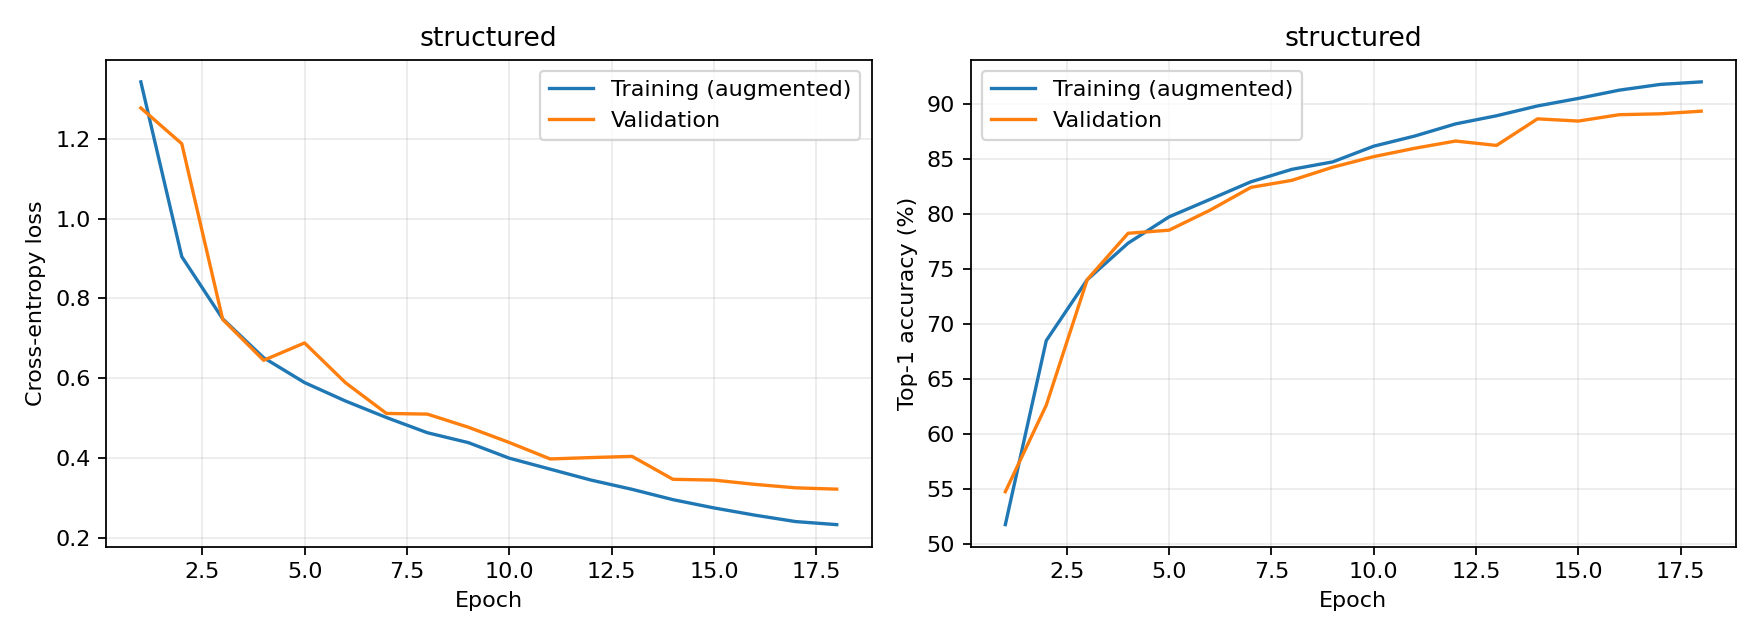

In [ ]:
display(Image(filename=str(ROOT / "figures" / "structured_curves.png")))


Structured inference uses 55,592,960 MACs per image versus 140,186,624 for the baseline. Its measured latency ratio is 1.580x baseline speed, and its absolute peak allocated memory is +35.725 MB lower than baseline. Its test accuracy drop is 4.15 percentage points. The broad assignment accuracy goal of at most 15 percentage points is met in this run. Physical channel removal reduces dense operation dimensions and state size, but measured speedup need not equal parameter reduction: unchanged stages, small-channel kernel efficiency, launch overhead, and the common input cache limit the gain. The common batch size makes this a throughput-oriented comparison; it is not a claim about single-image edge-device latency.


## Final verification and comparison

The final validation pass reloads the saved checkpoints, checks COO reconstruction and masked zeros, verifies equal unstructured budgets, and profiles inference without live optimizer state or training gradients. Its recorded audit is shown below.


#### Verify checkpoints and measure inference-only profiles


In [ ]:
def final_validation():
    """Run the original checkpoint checks and clean inference-only profiling pass.

    This function performs inference measurements and writes the final profiling files.
    """
    names = [
        "baseline",
        "local",
        "global",
        "iterative_magnitude",
        "iterative_grasp",
        "structured",
    ]
    audit = {
        "checkpoint_roundtrips": {},
        "all_final_mask_checks": True,
        "profiling_state": "No live optimizer, gradients, or GPU pruning masks.",
    }
    for name in names:
        gc.collect()
        torch.cuda.empty_cache()
        if name == "structured":
            model = load_structured()
        else:
            state = torch.load(
                ROOT / "checkpoints" / f"{name}_dense.pt",
                map_location="cpu",
                weights_only=True,
            )
            model = fresh(state)
            assert all(
                torch.equal(v.detach().cpu(), state[k])
                for k, v in model.state_dict().items()
            )
            del state
        model.zero_grad(set_to_none=True)
        model.eval()
        assert all(p.grad is None for p in model.parameters())
        counts = operation_counts(model)
        record = json.loads((ROOT / "results" / f"{name}_metrics.json").read_text())
        record.update(profile(model, name, counts))
        record["profiling_state"] = (
            "Inference-only checkpoint reload; no optimizer, gradients, or GPU masks."
        )
        save_json(name + "_metrics.json", record)
        audit["checkpoint_roundtrips"][name] = True
        if name in ["local", "global", "iterative_magnitude", "iterative_grasp"]:
            sparse_record = torch.load(
                ROOT / "checkpoints" / f"{name}_coo.pt",
                map_location="cpu",
                weights_only=True,
            )
            for n, m in eligible(model).items():
                t = sparse_record["sparse_tensors"][n + ".weight"]
                restored = (
                    torch.sparse_coo_tensor(
                        t["indices"], t["values"], t["shape"], check_invariants=True
                    )
                    .coalesce()
                    .to_dense()
                )
                assert torch.equal(restored, m.weight.detach().cpu())
                assert (restored[~t["mask"]] == 0).all()
            del sparse_record, restored, t
            sparse_model = coo_model(model)
            sample, _ = next(TEST.batches())
            with torch.inference_mode():
                torch.testing.assert_close(
                    model(sample), sparse_model(sample), atol=2e-4, rtol=2e-4
                )
            del sample
            model.cpu()
            gc.collect()
            torch.cuda.empty_cache()
            sparse_metrics = json.loads(
                (ROOT / "results" / f"{name}_coo_metrics.json").read_text()
            )
            sparse_metrics.update(profile(sparse_model, name + "_coo", counts))
            sparse_metrics["profiling_state"] = (
                "COO inference-only reload; dense source held on CPU."
            )
            save_json(name + "_coo_metrics.json", sparse_metrics)
            del sparse_model
        del model
        gc.collect()
        torch.cuda.empty_cache()
        print(
            "FINAL VALIDATION",
            name,
            "passed;",
            round(record["latency_ms"], 4),
            "ms/batch;",
            round(record["peak_GPU_MB"], 3),
            "MB peak",
            flush=True,
        )
    a = json.loads((ROOT / "results" / "local_metrics.json").read_text())
    b = json.loads((ROOT / "results" / "global_metrics.json").read_text())
    assert a["overall_sparsity"] == b["overall_sparsity"]
    for name in ["iterative_magnitude", "iterative_grasp"]:
        item = json.loads((ROOT / "results" / f"{name}_metrics.json").read_text())
        assert abs(item["overall_sparsity"] - a["overall_sparsity"]) < 1e-12
    audit["equal_unstructured_budgets"] = True
    audit["sensitivity_trials"] = len(pd.read_csv(ROOT / "results" / "sensitivity.csv"))
    assert audit["sensitivity_trials"] == 21 * 7
    for name in ["local", "global", "iterative_magnitude", "iterative_grasp"]:
        layers = pd.read_csv(ROOT / "results" / f"{name}_layers.csv")
        assert layers.masked_positions_zero.all()
    save_json("final_validation.json", audit)
    print(json.dumps(audit, indent=2), flush=True)
    return audit


In [ ]:
verification = final_validation()


{
  "checkpoint_roundtrips": {
    "baseline": true,
    "local": true,
    "global": true,
    "iterative_magnitude": true,
    "iterative_grasp": true,
    "structured": true
  },
  "all_final_mask_checks": true,
  "profiling_state": "No live optimizer, gradients, or GPU pruning masks.",
  "equal_unstructured_budgets": true,
  "sensitivity_trials": 147
}

### Accuracy comparison

| Model               |   Sparsity % |   Train Top-1 % |   Test Top-1 % |   Train Top-5 % |   Test Top-5 % |   Train macro-F1 |   Test macro-F1 |   Drop vs dense (pp) |
|:--------------------|-------------:|----------------:|---------------:|----------------:|---------------:|-----------------:|----------------:|---------------------:|
| Dense baseline      |       0.0000 |         99.8660 |        93.0700 |         99.9960 |        99.7400 |           0.9987 |          0.9307 |               0.0000 |
| Local magnitude     |      70.0000 |         98.1820 |        91.9700 |         99.9800 |        99.6900 |           0.9818 |          0.9196 |               1.1000 |
| Global magnitude    |      70.0000 |         96.4960 |        90.9300 |         99.9260 |        99.7300 |           0.9649 |          0.9092 |               2.1400 |
| Iterative magnitude |      70.0000 |         98.3560 |        90.5900 |         99.9700 |        99.6600 |           0.9835 |          0.9058 |               2.4800 |
| Iterative GraSP     |      70.0000 |         96.2300 |        88.5500 |         99.9240 |        99.5200 |           0.9622 |          0.8849 |               4.5200 |
| Structured channels |      70.0320 |         93.2280 |        88.9200 |         99.8340 |        99.5600 |           0.9322 |          0.8889 |               4.1500 |


### Model size and inference resources

| Model               |   Parameters |   Dense MB | COO MB     |   MACs/image |   FLOPs/image |   Latency ms/batch |   Peak GPU MB |   Average GPU MB |
|:--------------------|-------------:|-----------:|:-----------|-------------:|--------------:|-------------------:|--------------:|-----------------:|
| Dense baseline      |     11173962 |    44.7717 | N/A        |    140186624 |     280373248 |            12.2287 |      339.5205 |         267.6326 |
| Local magnitude     |     11173962 |    44.7713 | 131.840075 |    140186624 |     280373248 |            12.4733 |      339.5205 |         267.6326 |
| Global magnitude    |     11173962 |    44.7715 | 131.782517 |    140186624 |     280373248 |            12.3918 |      339.5215 |         267.6337 |
| Iterative magnitude |     11173962 |    44.7732 | 131.807127 |    140186624 |     280373248 |            12.1353 |      339.5215 |         267.6337 |
| Iterative GraSP     |     11173962 |    44.7726 | 131.847087 |    140186624 |     280373248 |            12.0313 |      339.5215 |         267.6337 |
| Structured channels |      3352678 |    13.4757 | N/A        |     55592960 |     111185920 |             7.7381 |      303.7957 |         236.6920 |


### Energy and measurement variability

| Model               |   GPU J/batch | CPU J/batch   |   Latency SD ms |   Incremental peak MB |
|:--------------------|--------------:|:--------------|----------------:|----------------------:|
| Dense baseline      |        0.8294 | N/A           |          0.1676 |               71.8930 |
| Local magnitude     |        0.8490 | N/A           |          0.1919 |               71.8930 |
| Global magnitude    |        0.8294 | N/A           |          0.1739 |               71.8930 |
| Iterative magnitude |        0.8192 | N/A           |          0.1412 |               71.8930 |
| Iterative GraSP     |        0.9518 | N/A           |          0.1600 |               71.8930 |
| Structured channels |        0.5403 | N/A           |          0.2127 |               67.1089 |


Final accuracy, latency, and dense model size on the same T4 GPU.


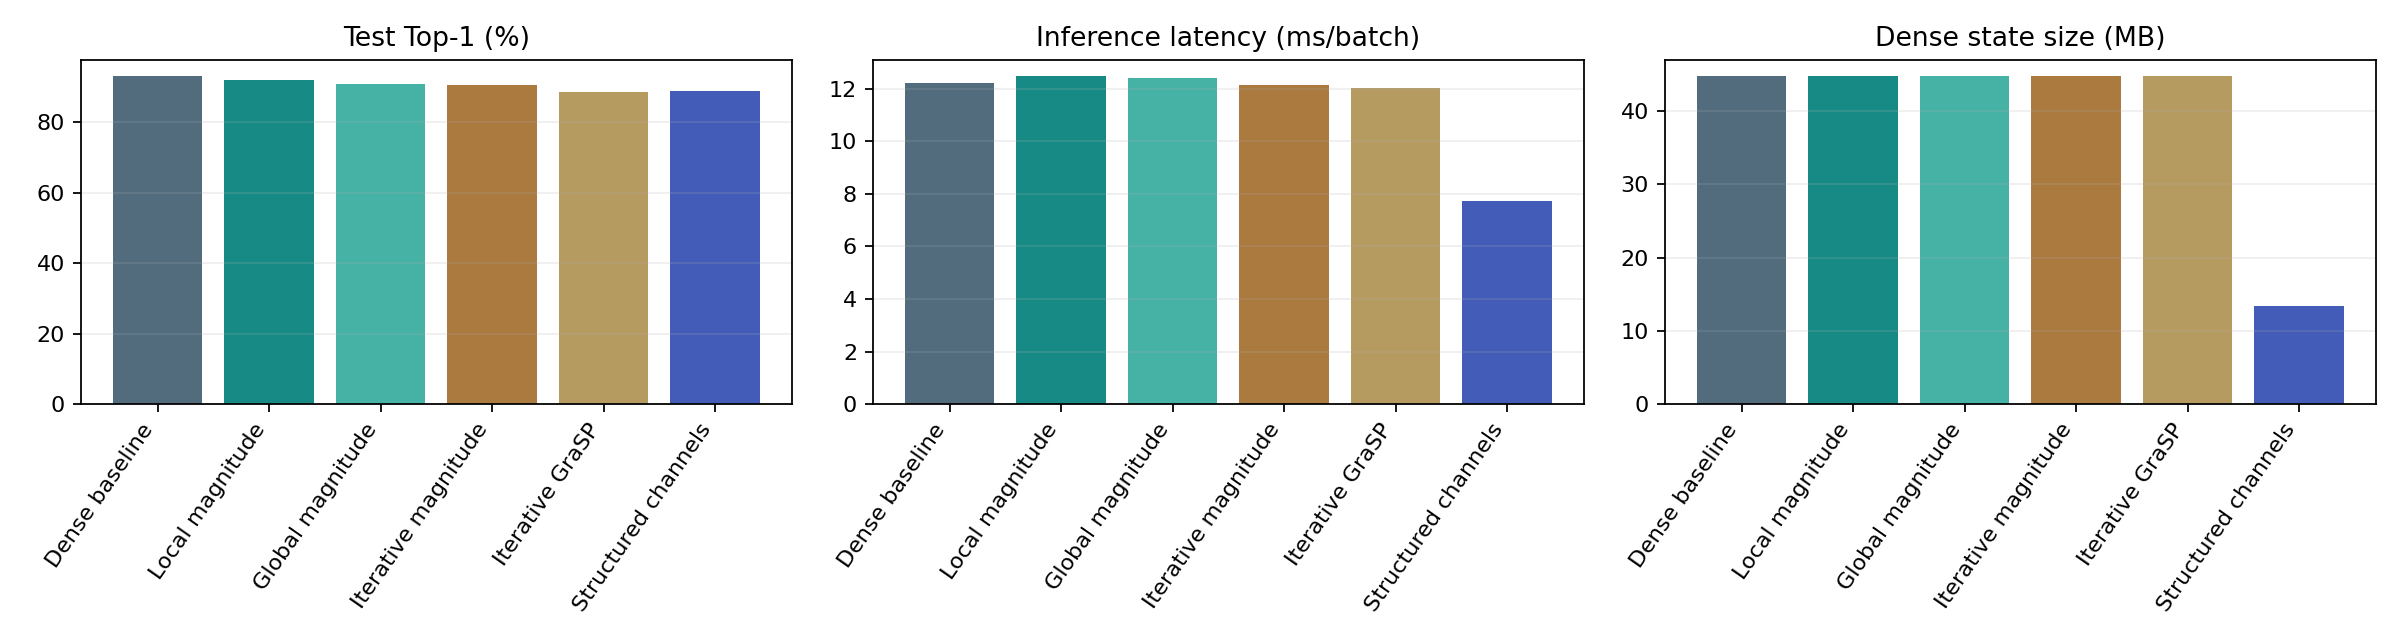

In [ ]:
display(Image(filename=str(ROOT / "figures" / "final_comparison.png")))


### Detailed final measurements

The following saved records retain all reported values, including precision beyond the rounded comparison tables.


In [ ]:
print((ROOT / "results" / "baseline_metrics.json").read_text())


{
  "train_n": 50000,
  "train_top1": 99.866,
  "train_top5": 99.996,
  "train_macro_f1": 0.9986599156285608,
  "train_loss": 0.02287079496860504,
  "test_n": 10000,
  "test_top1": 93.07,
  "test_top5": 99.74,
  "test_macro_f1": 0.9307003258502717,
  "test_loss": 0.2528163654565811,
  "parameters": 11173962,
  "dense_MB": 44.771723,
  "overall_sparsity": 0.0,
  "MACs": 140186624,
  "FLOPs": 280373248,
  "ideal_nonzero_MACs": 140186624,
  "latency_ms": 12.228656663894654,
  "latency_std_ms": 0.16761542800578316,
  "peak_GPU_MB": 339.520512,
  "average_GPU_MB": 267.63264,
  "incremental_peak_GPU_MB": 71.892992,
  "gpu_J_per_batch": 0.8294081669693094,
  "cpu_J_per_batch": null,
  "energy_note": "GPU: integrated NVML board power, not process-isolated. CPU: RAPL package counter when exposed; otherwise unavailable.",
  "gpu_power_error": null,
  "profile_batch_size": 128,
  "profile_batches": 100,
  "profiling_state": "Inference-only checkpoint reload; no optimizer, gradients, or GPU masks.

In [ ]:
print((ROOT / "results" / "local_metrics.json").read_text())


{
  "train_n": 50000,
  "train_top1": 98.182,
  "train_top5": 99.98,
  "train_macro_f1": 0.9818162766865708,
  "train_loss": 0.05770156232357025,
  "test_n": 10000,
  "test_top1": 91.97,
  "test_top5": 99.69,
  "test_macro_f1": 0.9195993752084002,
  "test_loss": 0.2669205296039581,
  "parameters": 11173962,
  "dense_MB": 44.771339,
  "overall_sparsity": 0.6999999641716779,
  "sparse_MB": 131.840075,
  "MACs": 140186624,
  "FLOPs": 280373248,
  "ideal_nonzero_MACs": 44468008,
  "latency_ms": 12.47333119392395,
  "latency_std_ms": 0.19194040791216874,
  "peak_GPU_MB": 339.520512,
  "average_GPU_MB": 267.63264,
  "incremental_peak_GPU_MB": 71.892992,
  "gpu_J_per_batch": 0.8489680702686493,
  "cpu_J_per_batch": null,
  "energy_note": "GPU: integrated NVML board power, not process-isolated. CPU: RAPL package counter when exposed; otherwise unavailable.",
  "gpu_power_error": null,
  "profile_batch_size": 128,
  "profile_batches": 100,
  "profiling_state": "Inference-only checkpoint reload;

In [ ]:
print((ROOT / "results" / "global_metrics.json").read_text())


{
  "train_n": 50000,
  "train_top1": 96.496,
  "train_top5": 99.926,
  "train_macro_f1": 0.9649425524117794,
  "train_loss": 0.10970585289001465,
  "test_n": 10000,
  "test_top1": 90.93,
  "test_top5": 99.73,
  "test_macro_f1": 0.9091892446698535,
  "test_loss": 0.2876444652557373,
  "parameters": 11173962,
  "dense_MB": 44.771467,
  "overall_sparsity": 0.6999999641716779,
  "sparse_MB": 131.782517,
  "MACs": 140186624,
  "FLOPs": 280373248,
  "ideal_nonzero_MACs": 95212090,
  "latency_ms": 12.391841259002685,
  "latency_std_ms": 0.17386487649786173,
  "peak_GPU_MB": 339.521536,
  "average_GPU_MB": 267.633664,
  "incremental_peak_GPU_MB": 71.892992,
  "gpu_J_per_batch": 0.8293791315922352,
  "cpu_J_per_batch": null,
  "energy_note": "GPU: integrated NVML board power, not process-isolated. CPU: RAPL package counter when exposed; otherwise unavailable.",
  "gpu_power_error": null,
  "profile_batch_size": 128,
  "profile_batches": 100,
  "profiling_state": "Inference-only checkpoint relo

In [ ]:
print((ROOT / "results" / "iterative_magnitude_metrics.json").read_text())


{
  "train_n": 50000,
  "train_top1": 98.356,
  "train_top5": 99.97,
  "train_macro_f1": 0.9835489354905891,
  "train_loss": 0.0581815579867363,
  "test_n": 10000,
  "test_top1": 90.59,
  "test_top5": 99.66,
  "test_macro_f1": 0.9058415659885405,
  "test_loss": 0.3362654311656952,
  "parameters": 11173962,
  "dense_MB": 44.773195,
  "overall_sparsity": 0.6999999641716779,
  "sparse_MB": 131.807127,
  "MACs": 140186624,
  "FLOPs": 280373248,
  "ideal_nonzero_MACs": 68331049,
  "latency_ms": 12.135301160812379,
  "latency_std_ms": 0.14121293962210515,
  "peak_GPU_MB": 339.521536,
  "average_GPU_MB": 267.633664,
  "incremental_peak_GPU_MB": 71.892992,
  "gpu_J_per_batch": 0.8191535536595637,
  "cpu_J_per_batch": null,
  "energy_note": "GPU: integrated NVML board power, not process-isolated. CPU: RAPL package counter when exposed; otherwise unavailable.",
  "gpu_power_error": null,
  "profile_batch_size": 128,
  "profile_batches": 100,
  "profiling_state": "Inference-only checkpoint reload

In [ ]:
print((ROOT / "results" / "iterative_grasp_metrics.json").read_text())


{
  "train_n": 50000,
  "train_top1": 96.23,
  "train_top5": 99.924,
  "train_macro_f1": 0.9621721847750209,
  "train_loss": 0.11810139340400695,
  "test_n": 10000,
  "test_top1": 88.55,
  "test_top5": 99.52,
  "test_macro_f1": 0.8849056447068013,
  "test_loss": 0.3761903339624405,
  "parameters": 11173962,
  "dense_MB": 44.772619,
  "overall_sparsity": 0.6999999641716779,
  "sparse_MB": 131.847087,
  "MACs": 140186624,
  "FLOPs": 280373248,
  "ideal_nonzero_MACs": 36199330,
  "latency_ms": 12.031321001052856,
  "latency_std_ms": 0.15999486101371732,
  "peak_GPU_MB": 339.521536,
  "average_GPU_MB": 267.633664,
  "incremental_peak_GPU_MB": 71.892992,
  "gpu_J_per_batch": 0.9518206276030686,
  "cpu_J_per_batch": null,
  "energy_note": "GPU: integrated NVML board power, not process-isolated. CPU: RAPL package counter when exposed; otherwise unavailable.",
  "gpu_power_error": null,
  "profile_batch_size": 128,
  "profile_batches": 100,
  "profiling_state": "Inference-only checkpoint reloa

In [ ]:
print((ROOT / "results" / "structured_metrics.json").read_text())


{
  "train_n": 50000,
  "train_top1": 93.228,
  "train_top5": 99.834,
  "train_macro_f1": 0.9321610228643393,
  "train_loss": 0.19932674455642702,
  "test_n": 10000,
  "test_top1": 88.92,
  "test_top5": 99.56,
  "test_macro_f1": 0.8888873549067909,
  "test_loss": 0.3409310471057892,
  "parameters": 3352678,
  "dense_MB": 13.475659,
  "overall_sparsity": 0.7003204485132679,
  "MACs": 55592960,
  "FLOPs": 111185920,
  "ideal_nonzero_MACs": 55592960,
  "latency_ms": 7.738081593513488,
  "latency_std_ms": 0.21271870136783858,
  "peak_GPU_MB": 303.795712,
  "average_GPU_MB": 236.691968,
  "incremental_peak_GPU_MB": 67.108864,
  "gpu_J_per_batch": 0.5402890794829703,
  "cpu_J_per_batch": null,
  "energy_note": "GPU: integrated NVML board power, not process-isolated. CPU: RAPL package counter when exposed; otherwise unavailable.",
  "gpu_power_error": null,
  "profile_batch_size": 128,
  "profile_batches": 100,
  "sparsity_definition": "Physical Conv/Linear weight-count reduction relative to 

## Limitations and interpretation

This submission reports one seed and one T4 GPU session. Hardware scheduling and GPU clocks can vary; latency standard deviation describes repeated batches, not uncertainty across independent machines. The scratch-training comparison has a fixed 50-epoch budget and may not have converged. Sensitivity and reconstruction use finite samples; layerwise independent sensitivity does not fully describe joint pruning interactions. Structured and unstructured sparsity use different physical representations and therefore different compute consequences, even when their eligible weight-removal budgets match. CPU energy is unavailable where host counters are not exposed. The included raw files make these limitations and all reported values auditable.


## References and code attribution

1. Huy Phan, *PyTorch CIFAR-10 models*: https://github.com/huyvnphan/PyTorch_CIFAR10 . Architecture and pretrained checkpoint only; experiment, pruning, profiling, and reporting code in this submission were written for this assignment.
2. Krizhevsky, *Learning Multiple Layers of Features from Tiny Images* (2009), CIFAR-10: https://www.cs.toronto.edu/~kriz/cifar.html .
3. Wang, Zhang, and Grosse, *Picking Winning Tickets Before Training by Preserving Gradient Flow* (ICLR 2020): https://arxiv.org/abs/2002.07376 . Signed GraSP scoring and ranking.
4. He, Zhang, and Sun, *Channel Pruning for Accelerating Very Deep Neural Networks* (ICCV 2017): https://arxiv.org/abs/1707.06168 . LASSO selection and least-squares reconstruction.
5. Han, Mao, and Dally, *Deep Compression* (ICLR 2016): https://arxiv.org/abs/1510.00149 . Magnitude pruning background.
6. PyTorch profiler documentation: https://docs.pytorch.org/tutorials/recipes/recipes/profiler_recipe.html .
7. PyTorch sparse tensors: https://docs.pytorch.org/docs/stable/sparse.html .
8. Official torchvision CIFAR-10 checksums: https://github.com/pytorch/vision/blob/main/torchvision/datasets/cifar.py . The mirror changes transport, not the dataset definition.
